In [1]:
print("Hello world")

Hello world


In [88]:
import pandas as pd
import numpy as np
from pymongo import MongoClient
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [89]:
#connecting to MongoDB client
client = MongoClient(
    "mongodb://100.103.177.85:27017",
    directConnection=True,
    serverSelectionTimeoutMS=10000,
)

db = client["booktestdbgp_test"]
print("Connected ✅")

Connected ✅


In [90]:
# Live Casino settled transactions only
# betParts ke andar se game name extract karna padega

raw_transactions = list(db["bet_transactions"].find(
    {
        "gameType": "Live Casino",
        "status": "SETTLED",
        "betParts": {"$exists": True, "$ne": []}
    }
))

transactions_df = pd.DataFrame(raw_transactions)
print(f"Raw transactions loaded: {len(transactions_df)}")
print(transactions_df.columns.tolist())

Raw transactions loaded: 197
['_id', 'category', 'gameType', 'ticketId', 'channel', 'status', 'createdDate', 'stake', 'currency', 'potentialPayout', 'isFreeBet', 'stakeBonus', 'stakeReal', 'minOdds', 'maxOdds', 'minPayout', 'maxPayout', 'freeBetId', 'bonusType', 'resultedDate', 'betType', 'betParts', 'cashoutHistory', 'dynamicMultiCorrectSelections', 'shortBetId', 'loginId', 'fromAccountId', 'fromAccountAmount', 'toAccountId', 'toAccountAmount', 'bonusAccountInfo', 'aggregatorId', 'aggregatorActionId', 'createdAt', 'updatedAt', '__v', 'payout', 'result', 'oddsChangeType', 'remainingStake', 'isPartialCoBet', 'totalOdds', 'cashoutStatus', 'bonusWinnings', 'bonusPercentage', 'groupCount', 'combinationCount', 'maxWinAmount', 'maxWinPercentage', 'clientMaxPayout', 'stakeTaxAmount', 'winningTaxAmount', 'stakeTax', 'winningTax', 'stakeAfterTax', 'totalStake', 'isNftHoldingCreated', 'isNftTraded', 'subBetType', 'betEligibleForOneCutBonus', 'betEligibleForTwoCutBonus', 'partialCoBet', 'maxPayou

In [91]:
# extracting first element of betParts array
# game name, vendor, category wahan hai

def extract_bet_part(betParts):
    if betParts and len(betParts) > 0:
        part = betParts[0]
        return {
            "sportName":    part.get("sportName", None),
            "categoryName": part.get("categoryName", None),
            "vendor":       part.get("tournamentName", None),
        }
    return {"sportName": None, "categoryName": None, "vendor": None}

bet_parts_expanded = transactions_df["betParts"].apply(extract_bet_part)
bet_parts_df = pd.DataFrame(bet_parts_expanded.tolist())

transactions_df = pd.concat(
    [transactions_df.drop(columns=["betParts"]), bet_parts_df], 
    axis=1
)

print(transactions_df[["loginId", "stake", "result", 
                         "sportName", "vendor", "categoryName"]].sample(5))

        loginId  stake result      sportName    vendor categoryName
136  6888888888   8000   LOSE        Aviator    Spribe   Crash Game
165  5111111111    200   LOSE   Super Sic Bo     EvoSW  Live Casino
155  7878787878    100    WIN   Super Sic Bo     EvoSW  Live Casino
186  4588888888   8000   LOSE        Aviator    Spribe   Crash Game
91   3265459874    100    WIN  Cricket Crash  OnlyPlay   Crash Game


In [92]:
# Rename fields to match recsys.ipynb schema
transactions_df = transactions_df.rename(columns={
    "loginId":      "userId",
    "stake":        "betAmount",
    "createdDate":  "timestamp",
    "sportName":    "gameName",
    "vendor":       "providerName",
})

# Time features
transactions_df["timestamp"] = pd.to_datetime(transactions_df["timestamp"])
transactions_df["hourOfDay"]  = transactions_df["timestamp"].dt.hour
transactions_df["dayOfWeek"]  = transactions_df["timestamp"].dt.day_name()

# Sirf jo chahiye
transactions_df = transactions_df[[
    "userId", "gameName", "providerName", "categoryName",
    "betAmount", "result",
    "timestamp", "hourOfDay", "dayOfWeek"
]].copy()

# Nulls drop
transactions_df = transactions_df.dropna(subset=["userId", "gameName", "betAmount"])

print(f"Clean transactions: {len(transactions_df)}")
print(transactions_df.dtypes)
print(transactions_df.sample(3))

Clean transactions: 144
userId                  object
gameName                object
providerName            object
categoryName            object
betAmount                int64
result                  object
timestamp       datetime64[ns]
hourOfDay                int32
dayOfWeek               object
dtype: object
         userId              gameName providerName categoryName  betAmount  \
144  7878787878                Bac Bo        EvoSW  Live Casino        100   
159  4588888888  Football Studio Dice        EvoSW  Live Casino        100   
167  5555533333          998:baccarat      Unknown       Casino        200   

    result               timestamp  hourOfDay dayOfWeek  
144   LOSE 2026-03-02 06:41:47.282          6    Monday  
159   LOSE 2026-03-03 06:41:00.428          6   Tuesday  
167   LOSE 2026-03-03 08:48:23.227          8   Tuesday  


In [93]:
#load games 

games_raw = list(db["gamedetails"].find(
    {"gameStatus": "ON"},
    {"gameId": 1, "gameName": 1, "minBet": 1, 
     "maxBet": 1, "category": 1, "gamevendor": 1}
))

games_df = pd.DataFrame(games_raw)

# Category name extract karo
games_df["gameType"] = games_df["category"].apply(
    lambda x: x[0]["name"] if x and len(x) > 0 else "Unknown"
)

games_df = games_df.rename(columns={"gameName": "gameName"})
games_df = games_df[["gameId", "gameName", "gameType", "minBet", "maxBet"]]

print(f"Games loaded: {len(games_df)}")
print(games_df.sample(5))

Games loaded: 76
     gameId                 gameName     gameType  minBet  maxBet
52  2610156             Hypersonic X        Crash     100  100000
14  1571008     Extreme Texas Holdem  Live Casino     100  100000
30  2331280  MONOPOLY Big Baller DNT  Live Casino     100  100000
72  2967002                   ScoreX        Crash     100  100000
70  2728194                Piggy Tap        Crash     100  100000


In [94]:
#load users

users_raw = list(db["players"].find(
    {"activeStatus": True},
    {"playerId": 1, "username": 1, "contactNo": 1, "activeStatus": 1}
))

users_df = pd.DataFrame(users_raw)

# userId consistent banana — transactions mein loginId = contactNo hai
users_df = users_df.rename(columns={"contactNo": "userId"})
users_df = users_df[["userId", "playerId", "activeStatus"]]

print(f"Users loaded: {len(users_df)}")
print(users_df.head(3))

Users loaded: 135
       userId  playerId  activeStatus
0  5555555555  10003490          True
1  5555577777  10003491          True
2  6677777777  10003492          True


In [95]:
print("=== DATA SUMMARY ===")
print(f"Transactions:   {len(transactions_df)}")
print(f"Unique users:   {transactions_df['userId'].nunique()}")
print(f"Unique games:   {transactions_df['gameName'].nunique()}")
print(f"Date range:     {transactions_df['timestamp'].min()} → {transactions_df['timestamp'].max()}")
print(f"\nGame distribution:")
print(transactions_df['gameName'].value_counts())
print(f"\nResult distribution:")
print(transactions_df['result'].value_counts())
print(f"\nNull check:")
print(transactions_df.isnull().sum())

=== DATA SUMMARY ===
Transactions:   144
Unique users:   18
Unique games:   12
Date range:     2026-02-19 09:19:13.543000 → 2026-03-03 12:27:35.929000

Game distribution:
gameName
Aviator                 35
Super Sic Bo            34
Cricket Crash           27
Quantum X               15
Dragon Tiger             9
Football studio          5
CosmoX                   5
998:baccarat             5
Football Studio Dice     5
Fan Tan                  2
Casino Hold'em           1
Bac Bo                   1
Name: count, dtype: int64

Result distribution:
result
LOSE    86
WIN     58
Name: count, dtype: int64

Null check:
userId          0
gameName        0
providerName    0
categoryName    0
betAmount       0
result          0
timestamp       0
hourOfDay       0
dayOfWeek       0
dtype: int64


In [100]:
# 1. Messy game names clean karo
game_name_map = {
    "998:baccarat": "Baccarat",
    "Football studio": "Football Studio",
}
transactions_df["gameName"] = transactions_df["gameName"].replace(game_name_map)

# 2. gameId add karo from games_df for joining
transactions_df = transactions_df.merge(
    games_df[["gameName", "gameId", "minBet", "maxBet"]],
    on="gameName",
    how="left"
)

# 3. result → binary win flag
transactions_df["win"] = (transactions_df["result"] == "WIN").astype(int)

print(f"After cleaning: {len(transactions_df)}")
print(f"Games with gameId matched: {transactions_df['gameId'].notna().sum()}")
print(transactions_df[["userId", "gameName", "gameId", "betAmount", "win"]].sample(5))

After cleaning: 179
Games with gameId matched: 169
         userId              gameName   gameId  betAmount  win
23   6258974310             Quantum X  2452312        107    1
110  5555533333          Super Sic Bo  1571026        100    1
52   6969696969         Cricket Crash  2553631       1000    1
127  4588888888  Football Studio Dice  2412792        100    0
129  4588888888  Football Studio Dice  2412792       5000    1


In [101]:
print("=== FINAL DATA READINESS CHECK ===")

# Transactions per user
txn_per_user = transactions_df.groupby("userId").size()
print(f"\nTransactions per user:")
print(txn_per_user.describe().round(2))
print(f"\nUsers with only 1 transaction: {(txn_per_user == 1).sum()}")
print(f"Users with 5+ transactions:    {(txn_per_user >= 5).sum()}")

# Games coverage
print(f"\nGames in transactions: {transactions_df['gameName'].nunique()}")
print(f"Games in games_df:     {len(games_df)}")

# User coverage
matched_users = transactions_df['userId'].isin(users_df['userId']).sum()
print(f"\nTransactions matched to players collection: {matched_users}/{len(transactions_df)}")

=== FINAL DATA READINESS CHECK ===

Transactions per user:
count    18.00
mean      9.94
std      11.64
min       1.00
25%       2.00
50%       6.50
75%      12.75
max      42.00
dtype: float64

Users with only 1 transaction: 3
Users with 5+ transactions:    10

Games in transactions: 12
Games in games_df:     76

Transactions matched to players collection: 179/179


In [102]:
#user session log 

db = client["booktestdbgp_test"]
count = db["usersessionlog"].estimated_document_count()
sample5 = list(db["usersessionlog"].find(
    {"source": "livecasino", "status": "Closed"}
).limit(5))

for s in sample5:
    duration = (s["updated_at"] - s["created_at"]).total_seconds()
    print(f"user: {s['user_id']} | game: {s['game_id']} | duration: {duration}s")

print(f"\nTotal session logs: {count}")
print(f"Live casino closed: {db['usersessionlog'].count_documents({'source': 'livecasino', 'status': 'Closed'})}")

user: 4333333333 | game: 1476419 | duration: 5.436s
user: 4333333333 | game: 1476422 | duration: 4.181s
user: 6258974310 | game: 1570996 | duration: 550.396s
user: 7878787878 | game: 1571026 | duration: 6.227s
user: 5555533333 | game: 1571026 | duration: 51.302s

Total session logs: 84
Live casino closed: 48


Current status — volume and quality notes

- Data is still sparse for robust model conclusions (few users/games/sessions).
- Short sessions (<30s) were identified as noise and are now filtered in the session-join step.
- Session-duration coverage remains partial after join, so duration-based features should be interpreted with care.
- Pipeline now uses schema-aligned proxies where fields are unavailable.

In [103]:
# Sabhi unique users ke sessions dekho
pipeline = [
    {"$match": {"source": "livecasino", "status": "Closed"}},
    {"$addFields": {
        "duration_seconds": {
            "$divide": [
                {"$subtract": ["$updated_at", "$created_at"]},
                1000
            ]
        }
    }},
    {"$group": {
        "_id": "$user_id",
        "total_sessions": {"$sum": 1},
        "avg_duration":   {"$avg": "$duration_seconds"},
        "max_duration":   {"$max": "$duration_seconds"},
        "min_duration":   {"$min": "$duration_seconds"},
    }},
    {"$sort": {"total_sessions": -1}}
]

print("=== Per User Session Stats ===")
for doc in db["usersessionlog"].aggregate(pipeline):
    print(f"user: {doc['_id']} | sessions: {doc['total_sessions']} | "
          f"avg: {doc['avg_duration']:.1f}s | "
          f"max: {doc['max_duration']:.1f}s | "
          f"min: {doc['min_duration']:.1f}s")

=== Per User Session Stats ===
user: 5555533333 | sessions: 23 | avg: 49.1s | max: 207.5s | min: 2.8s
user: 7878787878 | sessions: 8 | avg: 411.0s | max: 1721.6s | min: 2.0s
user: 7444444444 | sessions: 3 | avg: 48.2s | max: 72.6s | min: 16.0s
user: 4333333333 | sessions: 3 | avg: 6.7s | max: 10.5s | min: 4.2s
user: 6678480800 | sessions: 2 | avg: 6.2s | max: 7.3s | min: 5.1s
user: 7555555555 | sessions: 2 | avg: 54.2s | max: 77.0s | min: 31.4s
user: 6222222222 | sessions: 2 | avg: 30.6s | max: 48.6s | min: 12.7s
user: 9222222222 | sessions: 2 | avg: 63.8s | max: 68.1s | min: 59.6s
user: 4588888888 | sessions: 1 | avg: 311.7s | max: 311.7s | min: 311.7s
user: 5111111111 | sessions: 1 | avg: 51.6s | max: 51.6s | min: 51.6s
user: 6258974310 | sessions: 1 | avg: 550.4s | max: 550.4s | min: 550.4s


In [104]:
pipeline = [
    {"$match": {"source": "livecasino", "status": "Closed"}},
    {"$addFields": {
        "duration_seconds": {
            "$divide": [
                {"$subtract": ["$updated_at", "$created_at"]},
                1000
            ]
        }
    }},
    {"$group": {
        "_id": "$game_id",
        "total_sessions": {"$sum": 1},
        "avg_duration":   {"$avg": "$duration_seconds"},
        "max_duration":   {"$max": "$duration_seconds"},
        "min_duration":   {"$min": "$duration_seconds"},
    }},
    {"$sort": {"avg_duration": 1}}
]

# Game name join karo from gamedetails
results = list(db["usersessionlog"].aggregate(pipeline))

# gamedetails se name laao
game_lookup = {
    str(g["gameId"]): g["gameName"] 
    for g in db["gamedetails"].find({}, {"gameId": 1, "gameName": 1})
}

print(f"{'Game Name':<35} {'ID':<12} {'Sessions':<10} {'Avg(s)':<10} {'Max(s)':<10} {'Min(s)'}")
print("-" * 90)
for doc in results:
    game_id   = str(doc["_id"])
    game_name = game_lookup.get(game_id, "Unknown")
    print(f"{game_name:<35} {game_id:<12} {doc['total_sessions']:<10} "
          f"{doc['avg_duration']:<10.1f} {doc['max_duration']:<10.1f} {doc['min_duration']:.1f}")

Game Name                           ID           Sessions   Avg(s)     Max(s)     Min(s)
------------------------------------------------------------------------------------------
Bac Bo                              2156000      1          2.0        2.0        2.0
Ultimate Texas Holdem               1476419      1          5.4        5.4        5.4
Triple Card Poker                   1476422      5          21.3       48.6       2.8
Baccarat A (851)                    1476401      6          62.6       207.5      7.3
Dragon Tiger                        1571005      5          70.7       99.4       53.0
Fan Tan                             2058406      1          100.0      100.0      100.0
Super Sic Bo                        1571026      27         148.2      1721.6     2.8
Football Studio Dice                2412792      1          311.7      311.7      311.7
Tolkacova American Roulette         1570996      1          550.4      550.4      550.4


In [105]:
# Join usersessionlog with transactions_df
sessions_raw = list(db["usersessionlog"].find(
    {"source": "livecasino", "status": "Closed"}
))
sessions_df = pd.DataFrame(sessions_raw)
sessions_df["session_duration_sec"] = (
    sessions_df["updated_at"] - sessions_df["created_at"]
).dt.total_seconds()

# Bounce filter — 30s se kam sessions drop karo
sessions_df = sessions_df[sessions_df["session_duration_sec"] >= 30]
sessions_df = sessions_df.rename(columns={
    "user_id": "userId",
    "game_id": "gameId"
})

# Type match — dono side string karo
sessions_df["gameId"] = sessions_df["gameId"].astype(str)
transactions_df["gameId_str"] = (
    transactions_df["gameId"]
    .astype(str)
    .str.split(".")
    .str[0]
)

transactions_df = transactions_df.merge(
    sessions_df[["userId", "gameId", "session_duration_sec"]],
    left_on=["userId", "gameId_str"],
    right_on=["userId", "gameId"],
    how="left"
).drop(columns=["gameId_str", "gameId_y"], errors="ignore"
).rename(columns={"gameId_x": "gameId"})

matched = transactions_df["session_duration_sec"].notna().sum()
print(f"Transactions with session duration: {matched}/{len(transactions_df)}")
print(f"Coverage: {matched/len(transactions_df)*100:.1f}%")
print(transactions_df[["userId","gameName","betAmount","session_duration_sec"]].head(5))

Transactions with session duration: 111/254
Coverage: 43.7%
       userId      gameName  betAmount  session_duration_sec
0  7878787878  Super Sic Bo        400              1425.620
1  7878787878  Super Sic Bo        400              1721.644
2  7878787878  Super Sic Bo        400                59.102
3  6677777777  Super Sic Bo        400                   NaN
4  6677777777  Super Sic Bo        500                   NaN


## EDA — Real Data (for Hybrid LightFM Design)

This EDA uses the real live-casino dataset loaded above and focuses on recommendation-relevant behavior patterns.

### What this EDA covers
- Dataset overview (size, dtypes, missingness)
- User activity patterns (sessions/user, games/user)
- Game popularity and long-tail shape
- Distribution of game type and provider
- Engagement signals (`durationSeconds`, `roundsPlayed`, `exitType` proxies)
- Financial signals (`stakeLevelCategory`, `outcome`)
- Temporal signals (`timeOfDay`, `dayOfWeek`)
- Context signals (`deviceType`, `entryPoint` defaults)

> Note: Some schema fields are not directly present in source and are profiled using transparent proxies for EDA.

In [106]:
# EDA block: recommendation-focused analysis on real data

eda_df = transactions_df.copy()
eda_df['timestamp'] = pd.to_datetime(eda_df['timestamp'], errors='coerce')

# Bring duration proxy from merged session logs if available
if 'session_duration_sec' in eda_df.columns:
    eda_df['durationSeconds'] = pd.to_numeric(eda_df['session_duration_sec'], errors='coerce').fillna(0)
else:
    eda_df['durationSeconds'] = 0.0

# Proxy fields aligned to event schema for EDA only
eda_df['roundsPlayed'] = 1
eda_df['gameType_eda'] = eda_df.get('categoryName', 'live_dealer').astype(str)
eda_df['provider_eda'] = eda_df.get('providerName', 'HUB88').astype(str)
eda_df['outcome_eda'] = np.where(
    eda_df['result'].astype(str).str.upper().eq('WIN'),
    'net_positive',
    np.where(eda_df['result'].astype(str).str.upper().eq('LOSS'), 'net_negative', 'break_even')
)

stake = pd.to_numeric(eda_df['betAmount'], errors='coerce').fillna(0)
q1, q2 = stake.quantile([0.33, 0.66])
eda_df['stakeLevelCategory_eda'] = np.select(
    [stake <= q1, stake <= q2], ['low', 'medium'], default='high'
)

eda_df['timeOfDay_eda'] = np.select(
    [eda_df['hourOfDay'].between(6, 11), eda_df['hourOfDay'].between(12, 17), eda_df['hourOfDay'].between(18, 21)],
    ['morning', 'afternoon', 'evening'],
    default='late_night'
)
eda_df['dayOfWeek_eda'] = eda_df['dayOfWeek'].astype(str).str.lower()
eda_df['deviceType_eda'] = 'mobile'
eda_df['entryPoint_eda'] = 'direct'

# ExitType proxy
eda_df = eda_df.sort_values(['userId', 'timestamp']).reset_index(drop=True)
next_ts = eda_df.groupby('userId')['timestamp'].shift(-1)
gap_mins = (next_ts - eda_df['timestamp']).dt.total_seconds() / 60
eda_df['returnedWithin10mins_eda'] = gap_mins.le(10).fillna(False)
eda_df['exitType_eda'] = np.select(
    [eda_df['durationSeconds'] < 30, eda_df['returnedWithin10mins_eda']],
    ['quick_exit', 'returned_quickly'],
    default='natural_end'
)

print(f'Dataset rows: {len(eda_df):,}')
print(f'Unique users: {eda_df["userId"].nunique():,} | Unique games: {eda_df["gameName"].nunique():,}')
print('\nDtypes snapshot:')
print(eda_df[['userId','gameName','betAmount','timestamp','durationSeconds','roundsPlayed']].dtypes)
print('\nMissing values (top):')
print(eda_df.isnull().sum().sort_values(ascending=False).head(12))

Dataset rows: 254
Unique users: 18 | Unique games: 12

Dtypes snapshot:
userId                     object
gameName                   object
betAmount                   int64
timestamp          datetime64[ns]
durationSeconds           float64
roundsPlayed                int64
dtype: object

Missing values (top):
session_duration_sec        143
gameId                       10
minBet                       10
maxBet                       10
roundsPlayed                  0
returnedWithin10mins_eda      0
entryPoint_eda                0
deviceType_eda                0
dayOfWeek_eda                 0
timeOfDay_eda                 0
stakeLevelCategory_eda        0
outcome_eda                   0
dtype: int64


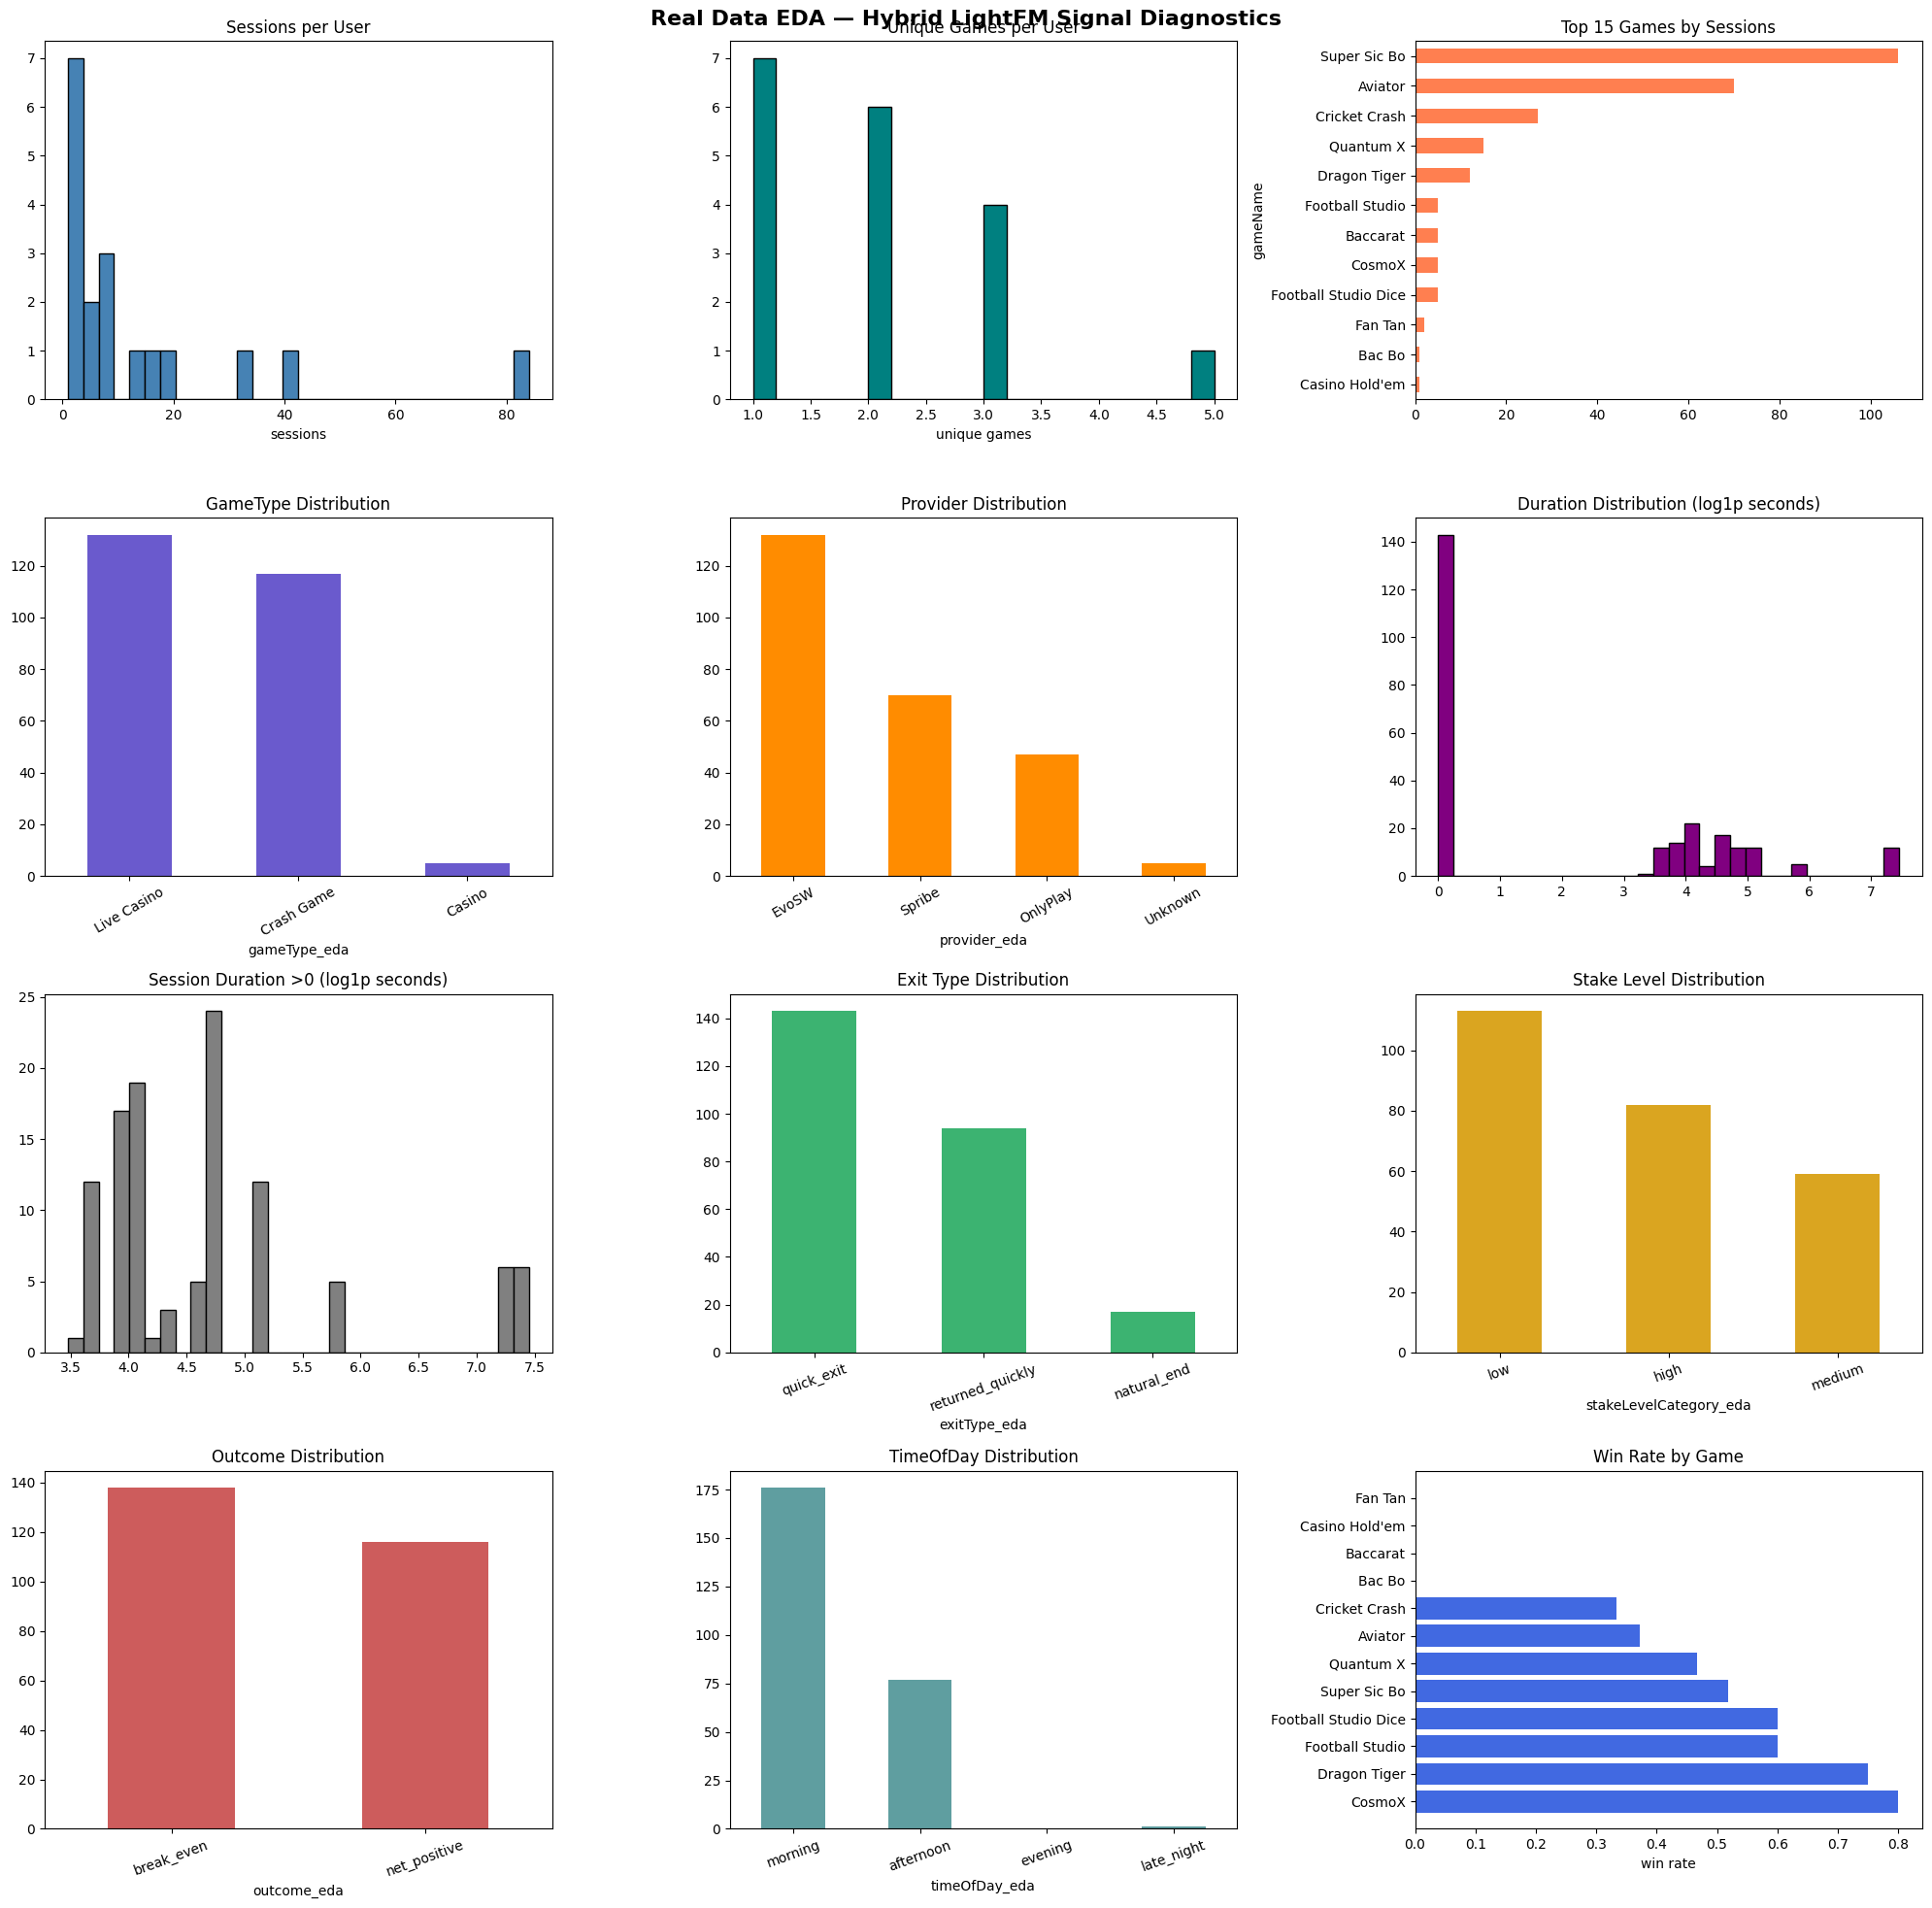

In [107]:
# EDA visualizations for hybrid LightFM signals

fig, axes = plt.subplots(4, 3, figsize=(20, 20))
fig.suptitle('Real Data EDA — Hybrid LightFM Signal Diagnostics', fontsize=16, fontweight='bold')

# 1) User activity: sessions per user
sessions_per_user = eda_df.groupby('userId').size()
axes[0, 0].hist(sessions_per_user, bins=30, color='steelblue', edgecolor='black')
axes[0, 0].set_title('Sessions per User')
axes[0, 0].set_xlabel('sessions')

# 2) User activity: games per user
games_per_user = eda_df.groupby('userId')['gameName'].nunique()
axes[0, 1].hist(games_per_user, bins=20, color='teal', edgecolor='black')
axes[0, 1].set_title('Unique Games per User')
axes[0, 1].set_xlabel('unique games')

# 3) Game popularity (top 15)
eda_df['gameName'].value_counts().head(15).sort_values().plot(kind='barh', ax=axes[0, 2], color='coral')
axes[0, 2].set_title('Top 15 Games by Sessions')

# 4) gameType distribution
eda_df['gameType_eda'].value_counts().plot(kind='bar', ax=axes[1, 0], color='slateblue')
axes[1, 0].set_title('GameType Distribution')
axes[1, 0].tick_params(axis='x', rotation=30)

# 5) provider distribution
eda_df['provider_eda'].value_counts().plot(kind='bar', ax=axes[1, 1], color='darkorange')
axes[1, 1].set_title('Provider Distribution')
axes[1, 1].tick_params(axis='x', rotation=30)

# 6) engagement: duration
axes[1, 2].hist(np.log1p(eda_df['durationSeconds']), bins=30, color='purple', edgecolor='black')
axes[1, 2].set_title('Duration Distribution (log1p seconds)')

# 7) engagement: session duration (non-zero only)
non_zero_duration = eda_df.loc[eda_df['durationSeconds'] > 0, 'durationSeconds']
axes[2, 0].hist(np.log1p(non_zero_duration), bins=30, color='gray', edgecolor='black')
axes[2, 0].set_title('Session Duration >0 (log1p seconds)')

# 8) engagement: exitType
eda_df['exitType_eda'].value_counts().plot(kind='bar', ax=axes[2, 1], color='mediumseagreen')
axes[2, 1].set_title('Exit Type Distribution')
axes[2, 1].tick_params(axis='x', rotation=20)

# 9) financial signals
eda_df['stakeLevelCategory_eda'].value_counts().plot(kind='bar', ax=axes[2, 2], color='goldenrod')
axes[2, 2].set_title('Stake Level Distribution')
axes[2, 2].tick_params(axis='x', rotation=20)

# 10) outcome
eda_df['outcome_eda'].value_counts().plot(kind='bar', ax=axes[3, 0], color='indianred')
axes[3, 0].set_title('Outcome Distribution')
axes[3, 0].tick_params(axis='x', rotation=20)

# 11) temporal patterns
eda_df['timeOfDay_eda'].value_counts().reindex(['morning','afternoon','evening','late_night'], fill_value=0).plot(kind='bar', ax=axes[3, 1], color='cadetblue')
axes[3, 1].set_title('TimeOfDay Distribution')
axes[3, 1].tick_params(axis='x', rotation=20)

# 12) win rate by game
win_rate_by_game = eda_df.groupby('gameName')['win'].mean().sort_values(ascending=False)
axes[3, 2].barh(win_rate_by_game.index, win_rate_by_game.values, color='royalblue')
axes[3, 2].set_title('Win Rate by Game')
axes[3, 2].set_xlabel('win rate')

plt.tight_layout()
plt.show()

### EDA Insights for Hybrid LightFM

- **Sparsity expectation**: sessions/user and games/user distributions indicate long-tail behavior, so user-game matrices will remain sparse.
- **Popularity bias risk**: top games dominate interactions; LightFM should keep metadata features (gameType/provider) to avoid over-recommending only head items.
- **Engagement quality**: `durationSeconds` and `exitType` can differentiate shallow vs high-intent sessions, useful for affinity weighting.
- **Financial segmentation**: `stakeLevelCategory` and `outcome` provide behavioral intensity context for user/game profiling.
- **Temporal/context behavior**: `timeOfDay`, `dayOfWeek`, and source-context fields should be retained as hybrid features when available.

These insights directly motivate the schema-aligned feature engineering in the next sections.

# Hybrid LightFM Recommendation Pipeline (Real Data)

Notebook structure:
1. **Data Loading** (raw ingestion + cleaning)
2. **EDA** (real behavior diagnostics for recommender design)
3. **Schema Alignment** (to TDD `game_session` event schema)
4. **Feature Engineering** (event, user, game, user-game features)
5. **LightFM Dataset Preparation** (model-ready table + sparsity diagnostics)

All logic uses real data only (no simulation, no random volume injection).

In [108]:
# Stage 2A: Utilities for schema alignment

SCHEMA_COLUMNS = [
    'eventType', 'userId', 'sessionId', 'gameId', 'gameType', 'provider', 'timestamp',
    'durationSeconds', 'roundsPlayed', 'stakeLevelCategory', 'outcome',
    'exitType', 'returnedWithin10mins',
    'deviceType', 'timeOfDay', 'dayOfWeek', 'entryPoint'
]

VALID_GAME_TYPES = ['slot', 'table', 'live_dealer', 'crash', 'instant_win']
VALID_PROVIDERS = ['HUB88', 'Evolution', 'EZUGI', 'Spribe', 'OnlyPlay']


def map_game_type(raw_value: str) -> str:
    value = str(raw_value).strip().lower()
    if any(k in value for k in ['live', 'baccarat', 'blackjack', 'roulette', 'sicbo', 'sic bo', 'dragon', 'teen patti', 'andar', 'football studio', 'fan tan', 'bac bo']):
        return 'live_dealer'
    if any(k in value for k in ['slot', 'starburst', 'fruit', 'reel']):
        return 'slot'
    if any(k in value for k in ['table', 'poker']):
        return 'table'
    if any(k in value for k in ['crash', 'aviator', 'cricket crash', 'quantum x', 'cosmox']):
        return 'crash'
    if any(k in value for k in ['instant', 'scratch', 'keno']):
        return 'instant_win'
    return 'live_dealer'


def map_provider(raw_value: str) -> str:
    value = str(raw_value).strip().lower()
    if any(k in value for k in ['evolution', 'evosw', 'evo']):
        return 'Evolution'
    if 'ezugi' in value:
        return 'EZUGI'
    if 'spribe' in value:
        return 'Spribe'
    if 'onlyplay' in value:
        return 'OnlyPlay'
    return 'HUB88'


def map_time_of_day(ts: pd.Series) -> pd.Series:
    hour = ts.dt.hour
    out = np.select(
        [hour.between(6, 11), hour.between(12, 17), hour.between(18, 21)],
        ['morning', 'afternoon', 'evening'],
        default='late_night'
    )
    return pd.Series(out, index=ts.index)


def map_day_of_week(ts: pd.Series) -> pd.Series:
    return ts.dt.day_name().str.lower()


def map_outcome(raw_result: pd.Series) -> pd.Series:
    value = raw_result.astype(str).str.upper()
    return np.where(
        value.eq('WIN'),
        'net_positive',
        np.where(value.eq('LOSS'), 'net_negative', 'break_even')
    )


print('Utilities loaded for schema alignment ✅')

Utilities loaded for schema alignment ✅


## Stage 2 — TDD Schema Alignment

Target event schema:
- eventType, userId, sessionId, gameId, gameType, provider, timestamp
- durationSeconds, roundsPlayed, stakeLevelCategory, outcome
- exitType, returnedWithin10mins
- deviceType, timeOfDay, dayOfWeek, entryPoint

Where raw fields are missing, defaults/assumptions are applied and logged for transparency.

In [109]:
# Stage 2B: Build schema-aligned event dataset


def align_to_event_schema(transactions_df: pd.DataFrame) -> pd.DataFrame:
    df = transactions_df.copy()

    # Ensure timestamp is datetime
    df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

    # Session id: use transaction id if present, else deterministic fallback
    if '_id' in df.columns:
        session_id = df['_id'].astype(str).map(lambda x: f'sess_{x}')
    else:
        session_id = pd.Series(range(len(df)), index=df.index).map(lambda x: f'sess_txn_{x}')

    # Game id: prefer canonical gameId if present, else slug from gameName
    if 'gameId' in df.columns:
        game_id = df['gameId'].astype(str)
    else:
        game_id = 'game_' + df['gameName'].astype(str).str.lower().str.replace(r'[^a-z0-9]+', '_', regex=True).str.strip('_')

    # Duration from session log merge if available; else 0
    if 'session_duration_sec' in df.columns:
        duration_seconds = pd.to_numeric(df['session_duration_sec'], errors='coerce').fillna(0)
    else:
        duration_seconds = pd.Series(0, index=df.index)

    # roundsPlayed proxy: one settled bet ~= one round
    rounds_played = pd.Series(1, index=df.index)

    # stake buckets from real stake distribution
    stake = pd.to_numeric(df['betAmount'], errors='coerce').fillna(0)
    q1, q2 = stake.quantile([0.33, 0.66])
    stake_level = np.select(
        [stake <= q1, stake <= q2],
        ['low', 'medium'],
        default='high'
    )

    aligned = pd.DataFrame({
        'eventType': 'game_session',
        'userId': df['userId'].astype(str),
        'sessionId': session_id,
        'gameId': game_id,
        'gameType': df.get('categoryName', df.get('gameType', 'live_dealer')).map(map_game_type),
        'provider': df.get('providerName', 'HUB88').map(map_provider),
        'timestamp': df['timestamp'],
        'durationSeconds': duration_seconds.astype(float),
        'roundsPlayed': rounds_played.astype(int),
        'stakeLevelCategory': stake_level,
        'outcome': map_outcome(df.get('result', pd.Series('break_even', index=df.index))),
        'deviceType': 'mobile',
        'entryPoint': 'direct',
    })

    aligned = aligned.sort_values(['userId', 'timestamp']).reset_index(drop=True)

    # return behavior: whether same user has another event within 10 mins
    next_ts = aligned.groupby('userId')['timestamp'].shift(-1)
    gap_mins = (next_ts - aligned['timestamp']).dt.total_seconds().div(60)
    aligned['returnedWithin10mins'] = gap_mins.le(10).fillna(False)

    # exit behavior from duration + return behavior
    aligned['exitType'] = np.select(
        [aligned['durationSeconds'] < 30, aligned['returnedWithin10mins']],
        ['quick_exit', 'returned_quickly'],
        default='natural_end'
    )

    aligned['timeOfDay'] = map_time_of_day(aligned['timestamp'])
    aligned['dayOfWeek'] = map_day_of_week(aligned['timestamp'])

    # enforce column order
    aligned = aligned[SCHEMA_COLUMNS]
    return aligned


events_df = align_to_event_schema(transactions_df)

print(f'Events shape: {events_df.shape}')
print('Schema columns present:', set(SCHEMA_COLUMNS).issubset(events_df.columns))
print(events_df.head(3))

Events shape: (254, 17)
Schema columns present: True
      eventType      userId    sessionId   gameId gameType  provider  \
0  game_session  3265459874  sess_txn_42  2553631    crash  OnlyPlay   
1  game_session  3265459874  sess_txn_43  2553631    crash  OnlyPlay   
2  game_session  3265459874  sess_txn_44  2553631    crash  OnlyPlay   

                timestamp  durationSeconds  roundsPlayed stakeLevelCategory  \
0 2026-02-24 10:17:21.714              0.0             1                low   
1 2026-02-24 10:17:34.883              0.0             1                low   
2 2026-02-24 10:17:53.646              0.0             1                low   

        outcome    exitType  returnedWithin10mins deviceType timeOfDay  \
0    break_even  quick_exit                  True     mobile   morning   
1    break_even  quick_exit                  True     mobile   morning   
2  net_positive  quick_exit                  True     mobile   morning   

  dayOfWeek entryPoint  
0   tuesday     dir

In [110]:
# Stage 2C: Schema mapping report (source -> schema)

schema_mapping = pd.DataFrame([
    {'schema_field': 'eventType', 'source_field': 'constant', 'mapping': '"game_session"'},
    {'schema_field': 'userId', 'source_field': 'loginId -> userId', 'mapping': 'direct rename'},
    {'schema_field': 'sessionId', 'source_field': '_id (fallback index)', 'mapping': 'sess_<id>'},
    {'schema_field': 'gameId', 'source_field': 'gameId (fallback gameName slug)', 'mapping': 'string cast / slug'},
    {'schema_field': 'gameType', 'source_field': 'categoryName / gameType', 'mapping': 'normalized into TDD enums'},
    {'schema_field': 'provider', 'source_field': 'providerName/vendor', 'mapping': 'mapped to HUB88/Evolution/EZUGI'},
    {'schema_field': 'timestamp', 'source_field': 'createdDate -> timestamp', 'mapping': 'datetime cast'},
    {'schema_field': 'durationSeconds', 'source_field': 'usersessionlog join', 'mapping': 'session_duration_sec else 0'},
    {'schema_field': 'roundsPlayed', 'source_field': 'proxy', 'mapping': '1 per settled event'},
    {'schema_field': 'stakeLevelCategory', 'source_field': 'betAmount', 'mapping': 'quantile buckets low/medium/high'},
    {'schema_field': 'outcome', 'source_field': 'result', 'mapping': 'WIN/LOSS/other -> net_positive/net_negative/break_even'},
    {'schema_field': 'exitType', 'source_field': 'durationSeconds + return gap', 'mapping': 'quick_exit/bonus_triggered/natural_end'},
    {'schema_field': 'returnedWithin10mins', 'source_field': 'next user event gap', 'mapping': '<=10 mins boolean'},
    {'schema_field': 'deviceType', 'source_field': 'not available', 'mapping': 'default "mobile" (assumption)'},
    {'schema_field': 'timeOfDay', 'source_field': 'timestamp hour', 'mapping': 'bucketed to late_night/morning/afternoon/evening'},
    {'schema_field': 'dayOfWeek', 'source_field': 'timestamp', 'mapping': 'lowercase weekday'},
    {'schema_field': 'entryPoint', 'source_field': 'not available', 'mapping': 'default "direct" (assumption)'},
])

print('Schema mapping table:')
display(schema_mapping)

Schema mapping table:


,schema_field,source_field,mapping
0,eventType,constant,"""game_session"""
1,userId,loginId -> userId,direct rename
2,sessionId,_id (fallback index),sess_<id>
3,gameId,gameId (fallback gameName slug),string cast / slug
4,gameType,categoryName / gameType,normalized into TDD enums
5,provider,providerName/vendor,mapped to HUB88/Evolution/EZUGI
6,timestamp,createdDate -> timestamp,datetime cast
7,durationSeconds,usersessionlog join,session_duration_sec else 0
8,roundsPlayed,proxy,1 per settled event
9,stakeLevelCategory,betAmount,quantile buckets low/medium/high


In [111]:
# Stage 3A: Event-level feature engineering

fe_events = events_df.copy()

# Session behavior features
fe_events['is_quick_exit'] = (fe_events['exitType'] == 'quick_exit').astype(int)
fe_events['is_positive_outcome'] = (fe_events['outcome'] == 'net_positive').astype(int)
fe_events['is_negative_outcome'] = (fe_events['outcome'] == 'net_negative').astype(int)

# Engagement intensity proxy
stake_weight = fe_events['stakeLevelCategory'].map({'low': 1, 'medium': 2, 'high': 3}).fillna(1)
fe_events['engagement_intensity'] = (
    np.log1p(fe_events['durationSeconds'].clip(lower=0)) * 0.5
    + fe_events['roundsPlayed'].clip(lower=0) * 0.3
    + stake_weight * 0.2
)

# User recency features
fe_events = fe_events.sort_values(['userId', 'timestamp']).reset_index(drop=True)
prev_ts = fe_events.groupby('userId')['timestamp'].shift(1)
fe_events['minutes_since_prev_event'] = (fe_events['timestamp'] - prev_ts).dt.total_seconds().div(60)
fe_events['minutes_since_prev_event'] = fe_events['minutes_since_prev_event'].fillna(1e6)

print('Event-level features created ✅')
print(fe_events[['engagement_intensity', 'is_quick_exit', 'is_positive_outcome', 'minutes_since_prev_event']].describe().round(3))

Event-level features created ✅
       engagement_intensity  is_quick_exit  is_positive_outcome  \
count               254.000        254.000              254.000   
mean                  1.710          0.563                0.457   
std                   1.143          0.497                0.499   
min                   0.500          0.000                0.000   
25%                   0.700          0.000                0.000   
50%                   0.900          1.000                0.000   
75%                   2.682          1.000                1.000   
max                   4.426          1.000                1.000   

       minutes_since_prev_event  
count                   254.000  
mean                  71025.702  
std                  257066.466  
min                       0.000  
25%                       0.000  
50%                       0.196  
75%                       0.722  
max                 1000000.000  


In [112]:
# Stage 3B: User-level features (schema-driven)

user_features_df = fe_events.groupby('userId').agg(
    total_sessions=('sessionId', 'count'),
    unique_games=('gameId', 'nunique'),
    unique_providers=('provider', 'nunique'),
    unique_game_types=('gameType', 'nunique'),
    avg_duration_sec=('durationSeconds', 'mean'),
    avg_rounds=('roundsPlayed', 'mean'),
    quick_exit_rate=('is_quick_exit', 'mean'),
    return_10m_rate=('returnedWithin10mins', 'mean'),
    positive_outcome_rate=('is_positive_outcome', 'mean'),
    avg_engagement_intensity=('engagement_intensity', 'mean'),
    preferred_time_of_day=('timeOfDay', lambda x: x.mode().iat[0] if len(x.mode()) else 'late_night'),
    preferred_day_of_week=('dayOfWeek', lambda x: x.mode().iat[0] if len(x.mode()) else 'friday'),
    preferred_device=('deviceType', lambda x: x.mode().iat[0] if len(x.mode()) else 'mobile'),
    preferred_entry_point=('entryPoint', lambda x: x.mode().iat[0] if len(x.mode()) else 'direct'),
    last_event_ts=('timestamp', 'max'),
).reset_index()

max_ts = fe_events['timestamp'].max()
user_features_df['recency_days'] = (max_ts - user_features_df['last_event_ts']).dt.total_seconds().div(86400)

print(f'User features shape: {user_features_df.shape}')
user_features_df.head(3)

User features shape: (18, 17)


,userId,total_sessions,unique_games,unique_providers,unique_game_types,avg_duration_sec,avg_rounds,quick_exit_rate,return_10m_rate,positive_outcome_rate,avg_engagement_intensity,preferred_time_of_day,preferred_day_of_week,preferred_device,preferred_entry_point,last_event_ts,recency_days
0,3265459874,9,3,2,2,0.000000,1.0,1.000000,0.777778,0.444444,0.500000,morning,tuesday,mobile,direct,2026-02-24 10:54:10.626,7.064876
1,3265967463,3,1,1,1,0.000000,1.0,1.000000,0.666667,0.333333,0.500000,afternoon,tuesday,mobile,direct,2026-02-24 13:16:20.785,6.966147
2,4588888888,33,2,2,2,47.228182,1.0,0.848485,0.939394,0.212121,1.323126,afternoon,tuesday,mobile,direct,2026-03-03 12:27:35.929,0.000000


## Stage 3 — Schema-Driven Feature Engineering

Features are built from aligned event fields:
- Session behavior (duration, rounds proxy, exit behavior)
- Engagement signals (return behavior, quick exits)
- Preference signals (game, gameType, provider)
- Temporal patterns (timeOfDay, dayOfWeek)
- Device/context patterns (deviceType, entryPoint)
- Recency-frequency and user-game affinity signals

In [113]:
# Stage 3C: Game and provider features

game_features_df = fe_events.groupby('gameId').agg(
    game_sessions=('sessionId', 'count'),
    unique_users=('userId', 'nunique'),
    game_type=('gameType', lambda x: x.mode().iat[0] if len(x.mode()) else 'live_dealer'),
    provider=('provider', lambda x: x.mode().iat[0] if len(x.mode()) else 'HUB88'),
    avg_duration_sec=('durationSeconds', 'mean'),
    avg_rounds=('roundsPlayed', 'mean'),
    quick_exit_rate=('is_quick_exit', 'mean'),
    return_10m_rate=('returnedWithin10mins', 'mean'),
    positive_outcome_rate=('is_positive_outcome', 'mean'),
).reset_index()

game_features_df['popularity_score'] = np.log1p(game_features_df['game_sessions'])

provider_features_df = fe_events.groupby('provider').agg(
    provider_sessions=('sessionId', 'count'),
    provider_unique_users=('userId', 'nunique'),
    provider_avg_engagement=('engagement_intensity', 'mean'),
).reset_index()

print(f'Game features shape: {game_features_df.shape}')
print(f'Provider features shape: {provider_features_df.shape}')
game_features_df.head(3)

Game features shape: (11, 11)
Provider features shape: (4, 4)


,gameId,game_sessions,unique_users,game_type,provider,avg_duration_sec,avg_rounds,quick_exit_rate,return_10m_rate,positive_outcome_rate,popularity_score
0,1476410,1,1,live_dealer,Evolution,0.000000,1.0,1.000000,0.000000,0.000000,0.693147
1,1571005,12,5,live_dealer,Evolution,67.687250,1.0,0.083333,0.666667,0.750000,2.564949
2,1571026,106,8,live_dealer,Evolution,244.001226,1.0,0.122642,0.867925,0.518868,4.672829


In [114]:
# Stage 4: User-game affinity + interaction features

user_game_df = fe_events.groupby(['userId', 'gameId']).agg(
    interaction_count=('sessionId', 'count'),
    avg_duration_sec=('durationSeconds', 'mean'),
    avg_rounds=('roundsPlayed', 'mean'),
    positive_outcome_rate=('is_positive_outcome', 'mean'),
    return_10m_rate=('returnedWithin10mins', 'mean'),
    avg_engagement_intensity=('engagement_intensity', 'mean'),
    last_interaction_ts=('timestamp', 'max'),
    dominant_game_type=('gameType', lambda x: x.mode().iat[0] if len(x.mode()) else 'live_dealer'),
    dominant_provider=('provider', lambda x: x.mode().iat[0] if len(x.mode()) else 'HUB88'),
).reset_index()

max_ts = fe_events['timestamp'].max()
user_game_df['recency_days'] = (max_ts - user_game_df['last_interaction_ts']).dt.total_seconds().div(86400)

# Implicit score inspired by recsys.ipynb pattern (frequency + quality + recency)
freq_score = np.minimum(user_game_df['interaction_count'] / 20.0, 1.0)
engagement_score = np.minimum(user_game_df['avg_engagement_intensity'] / np.maximum(user_game_df['avg_engagement_intensity'].quantile(0.95), 1e-6), 1.0)
quality_score = user_game_df['positive_outcome_rate'].fillna(0)
recency_weight = np.where(
    user_game_df['recency_days'] <= 7, 1.0,
    np.where(user_game_df['recency_days'] <= 30, 0.7, np.where(user_game_df['recency_days'] <= 90, 0.4, 0.2))
)

user_game_df['implicit_score'] = (
    0.40 * freq_score
    + 0.25 * engagement_score
    + 0.15 * quality_score
    + 0.20 * recency_weight
).round(4)

print(f'User-game interactions: {user_game_df.shape}')
print(user_game_df['implicit_score'].describe().round(3))

User-game interactions: (36, 13)
count    36.000
mean      0.424
std       0.172
min       0.199
25%       0.315
50%       0.372
75%       0.460
max       0.915
Name: implicit_score, dtype: float64


In [115]:
# Stage 5: LightFM dataset preparation (model-ready table)

model_ready_df = (
    user_game_df
    .merge(user_features_df.drop(columns=['last_event_ts']), on='userId', how='left')
    .merge(game_features_df, on='gameId', how='left', suffixes=('_ug', '_g'))
)

# Clean NA values for model readiness
numeric_cols = model_ready_df.select_dtypes(include=[np.number]).columns
categorical_cols = model_ready_df.select_dtypes(exclude=[np.number, 'datetime64[ns]']).columns

model_ready_df[numeric_cols] = model_ready_df[numeric_cols].fillna(0)
model_ready_df[categorical_cols] = model_ready_df[categorical_cols].fillna('unknown')

print(f'Model-ready dataset shape: {model_ready_df.shape}')
print('Sample columns:', model_ready_df.columns[:20].tolist())
model_ready_df.head(3)

Model-ready dataset shape: (36, 38)
Sample columns: ['userId', 'gameId', 'interaction_count', 'avg_duration_sec_x', 'avg_rounds_x', 'positive_outcome_rate_x', 'return_10m_rate_x', 'avg_engagement_intensity_x', 'last_interaction_ts', 'dominant_game_type', 'dominant_provider', 'recency_days_x', 'implicit_score', 'total_sessions', 'unique_games', 'unique_providers', 'unique_game_types', 'avg_duration_sec_y', 'avg_rounds_y', 'quick_exit_rate_ug']


,userId,gameId,interaction_count,avg_duration_sec_x,avg_rounds_x,positive_outcome_rate_x,return_10m_rate_x,avg_engagement_intensity_x,last_interaction_ts,dominant_game_type,...,game_sessions,unique_users,game_type,provider,avg_duration_sec,avg_rounds,quick_exit_rate_g,return_10m_rate,positive_outcome_rate,popularity_score
0,3265459874,1476410,1,0.0,1.0,0.000000,0.0,0.5,2026-02-24 10:32:54.747,live_dealer,...,1,1,live_dealer,Evolution,0.000000,1.0,1.000000,0.000000,0.000000,0.693147
1,3265459874,1571026,1,0.0,1.0,1.000000,0.0,0.5,2026-02-24 10:54:10.626,live_dealer,...,106,8,live_dealer,Evolution,244.001226,1.0,0.122642,0.867925,0.518868,4.672829
2,3265459874,2553631,7,0.0,1.0,0.428571,1.0,0.5,2026-02-24 10:29:28.040,crash,...,27,6,crash,OnlyPlay,0.000000,1.0,1.000000,0.777778,0.333333,3.332205


=== Recommendation Data Geometry ===
Events:               254
Users:                18
Games:                11
User-game pairs:      36
Interaction density:  18.1818%


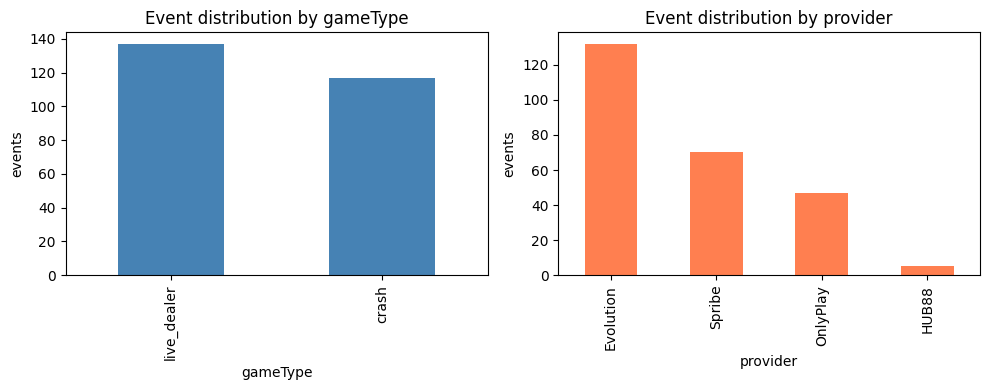

In [116]:
# Stage 5B: Lightweight diagnostics for coverage and sparsity

n_users = events_df['userId'].nunique()
n_games = events_df['gameId'].nunique()
n_pairs = user_game_df.groupby(['userId', 'gameId']).ngroups
density = n_pairs / max(n_users * n_games, 1)

print('=== Recommendation Data Geometry ===')
print(f'Events:               {len(events_df):,}')
print(f'Users:                {n_users:,}')
print(f'Games:                {n_games:,}')
print(f'User-game pairs:      {n_pairs:,}')
print(f'Interaction density:  {density * 100:.4f}%')

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
events_df['gameType'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Event distribution by gameType')
plt.xlabel('gameType')
plt.ylabel('events')

plt.subplot(1, 2, 2)
events_df['provider'].value_counts().plot(kind='bar', color='coral')
plt.title('Event distribution by provider')
plt.xlabel('provider')
plt.ylabel('events')

plt.tight_layout()
plt.show()

## Stage 6 — Hybrid LightFM Model Training

This section trains LightFM on schema-aligned real-data interactions with user/item metadata features.

In [117]:
from lightfm import LightFM
from lightfm.data import Dataset
from lightfm.cross_validation import random_train_test_split
from lightfm.evaluation import precision_at_k, auc_score
from scipy.sparse import csr_matrix

SEED = 42

active_users = user_game_df['userId'].astype(str).unique()
active_items = user_game_df['gameId'].astype(str).unique()

ufe = user_features_df[user_features_df['userId'].astype(str).isin(active_users)].copy()
ife = game_features_df[game_features_df['gameId'].astype(str).isin(active_items)].copy()

# Ensure behavioral bucket cols are available in ufe if present in user_features_df
for col in ['user_recency_bucket', 'loyalty_bucket', 'aggr_bet_bucket']:
    if col not in ufe.columns and col in user_features_df.columns:
        ufe = ufe.merge(user_features_df[['userId', col]], on='userId', how='left')

ife['popularity_bucket'] = pd.qcut(
    ife['popularity_score'].rank(method='first'),
    q=min(4, max(1, len(ife))),
    labels=['cold', 'warm', 'hot', 'blockbuster'][:min(4, max(1, len(ife)))]
).astype(str)

def user_tokens(row):
    tokens = [
        f"preferred_time_of_day:{row['preferred_time_of_day']}",
        f"preferred_day_of_week:{row['preferred_day_of_week']}",
    ]
    for col, prefix in [('user_recency_bucket', 'user_recency_bucket'),
                        ('loyalty_bucket', 'loyalty_bucket'),
                        ('aggr_bet_bucket', 'aggr_bet_bucket')]:
        val = row.get(col)
        if pd.notna(val) and str(val) not in ('nan', 'unknown', 'None'):
            tokens.append(f"{prefix}:{val}")
    return tokens

def item_tokens(row):
    return [
        f"game_type:{row['game_type']}",
        f"provider:{row['provider']}",
        f"popularity_bucket:{row['popularity_bucket']}",
    ]

user_feature_vocab = sorted({tok for _, r in ufe.iterrows() for tok in user_tokens(r)})
item_feature_vocab = sorted({tok for _, r in ife.iterrows() for tok in item_tokens(r)})

dataset = Dataset()
dataset.fit(
    users=active_users,
    items=active_items,
    user_features=user_feature_vocab,
    item_features=item_feature_vocab,
)

(interactions, weights) = dataset.build_interactions(
    (str(r['userId']), str(r['gameId']), float(r['implicit_score']))
    for _, r in user_game_df.iterrows()
)

user_features_matrix = dataset.build_user_features(
    (str(r['userId']), user_tokens(r)) for _, r in ufe.iterrows()
)
item_features_matrix = dataset.build_item_features(
    (str(r['gameId']), item_tokens(r)) for _, r in ife.iterrows()
)

train_interactions, test_interactions = random_train_test_split(
    interactions,
    random_state=np.random.RandomState(SEED),
    test_percentage=0.20,
)

print('LightFM artifacts built ✅')
print('Interactions:', interactions.shape, '| nnz =', interactions.nnz)
print('Train nnz:', train_interactions.nnz, '| Test nnz:', test_interactions.nnz)
print('User feature matrix:', user_features_matrix.shape)
print('Item feature matrix:', item_features_matrix.shape)

LightFM artifacts built ✅
Interactions: (18, 11) | nnz = 36
Train nnz: 28 | Test nnz: 8
User feature matrix: (18, 26)
Item feature matrix: (11, 20)


In [118]:
# Train LightFM

model = LightFM(
    no_components=32,
    loss='warp',
    learning_rate=0.03,
    item_alpha=1e-6,
    user_alpha=1e-6,
    random_state=SEED,
)

N_EPOCHS = 20
train_hist, test_hist = [], []

for epoch in range(N_EPOCHS):
    model.fit_partial(
        interactions=train_interactions,
        user_features=user_features_matrix,
        item_features=item_features_matrix,
        num_threads=4,
        epochs=1,
    )

    if (epoch + 1) % 5 == 0:
        tr_p = precision_at_k(
            model, train_interactions,
            user_features=user_features_matrix,
            item_features=item_features_matrix,
            k=5, num_threads=4,
        ).mean()
        te_p = precision_at_k(
            model, test_interactions,
            user_features=user_features_matrix,
            item_features=item_features_matrix,
            k=5, num_threads=4,
        ).mean()
        train_hist.append(float(tr_p))
        test_hist.append(float(te_p))
        print(f'Epoch {epoch+1:2d}/{N_EPOCHS} | Train P@5: {tr_p:.4f} | Test P@5: {te_p:.4f}')

print('Training complete ✅')

Epoch  5/20 | Train P@5: 0.2625 | Test P@5: 0.1143
Epoch 10/20 | Train P@5: 0.2625 | Test P@5: 0.1143
Epoch 15/20 | Train P@5: 0.2625 | Test P@5: 0.1143
Epoch 20/20 | Train P@5: 0.2625 | Test P@5: 0.1143
Training complete ✅


## Stage 7 — Evaluation & Recommendation Preview

Primary metrics:
- Precision@10
- AUC
- Learning trend across checkpoints

Also includes sample top-N recommendations for a real user.

LightFM Evaluation Summary
Train Precision@5: 0.2625
Test  Precision@5: 0.1143
Train AUC:         0.7637
Test  AUC:         0.6238
NDCG@5:            0.3962
Generalization gap: 0.1482


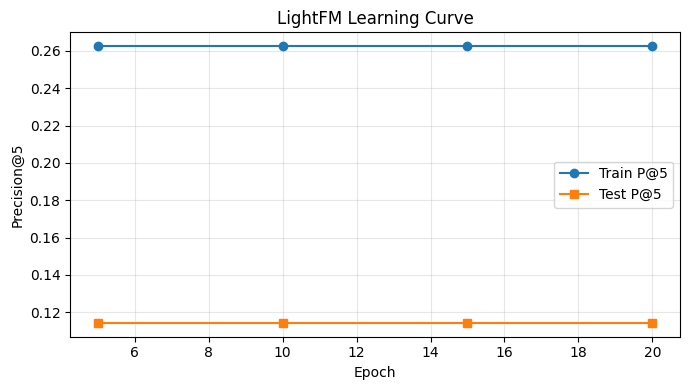


Sample recommendations for user: 3265459874


,gameId,score
0,nan,-0.716296
1,2965727,-0.812340
2,2452312,-0.841089
3,2412792,-0.851048
4,1571005,-0.861031


In [119]:
# Evaluation metrics + sample recommendations

from sklearn.metrics import ndcg_score

final_train_p5 = precision_at_k(
    model, train_interactions,
    user_features=user_features_matrix,
    item_features=item_features_matrix,
    k=5, num_threads=4,
).mean()

final_test_p5 = precision_at_k(
    model, test_interactions,
    user_features=user_features_matrix,
    item_features=item_features_matrix,
    k=5, num_threads=4,
).mean()

final_train_auc = auc_score(
    model, train_interactions,
    user_features=user_features_matrix,
    item_features=item_features_matrix,
    num_threads=4,
).mean()

final_test_auc = auc_score(
    model, test_interactions,
    user_features=user_features_matrix,
    item_features=item_features_matrix,
    num_threads=4,
).mean()

# NDCG@5 on users with test interactions
n_users_eval, n_items_eval = test_interactions.shape
test_csr_eval = csr_matrix(test_interactions)
ndcg_vals = []
for user_idx in range(n_users_eval):
    true_items = test_csr_eval.getrow(user_idx).indices
    if len(true_items) == 0:
        continue
    scores = model.predict(
        user_ids=np.repeat(user_idx, n_items_eval),
        item_ids=np.arange(n_items_eval),
        user_features=user_features_matrix,
        item_features=item_features_matrix,
        num_threads=4,
    )
    y_true = np.zeros(n_items_eval)
    y_true[true_items] = 1
    ndcg_vals.append(ndcg_score([y_true], [scores], k=5))

final_ndcg5 = float(np.mean(ndcg_vals)) if len(ndcg_vals) > 0 else float('nan')

print('=' * 52)
print('LightFM Evaluation Summary')
print('=' * 52)
print(f'Train Precision@5: {final_train_p5:.4f}')
print(f'Test  Precision@5: {final_test_p5:.4f}')
print(f'Train AUC:         {final_train_auc:.4f}')
print(f'Test  AUC:         {final_test_auc:.4f}')
print(f'NDCG@5:            {final_ndcg5:.4f}')
print(f'Generalization gap: {(final_train_p5 - final_test_p5):.4f}')

if len(train_hist) > 0:
    ckpts = [5 * (i + 1) for i in range(len(train_hist))]
    plt.figure(figsize=(7, 4))
    plt.plot(ckpts, train_hist, marker='o', label='Train P@5')
    plt.plot(ckpts, test_hist, marker='s', label='Test P@5')
    plt.title('LightFM Learning Curve')
    plt.xlabel('Epoch')
    plt.ylabel('Precision@5')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# Recommendation preview helper
user_id_map, user_feat_map, item_id_map, item_feat_map = dataset.mapping()
idx_to_item = {idx: item for item, idx in item_id_map.items()}

train_csr = csr_matrix(train_interactions)
all_item_ids = np.arange(train_csr.shape[1])

def recommend_for_user(raw_user_id: str, k: int = 5):
    if raw_user_id not in user_id_map:
        return pd.DataFrame(columns=['gameId', 'score'])

    uid = user_id_map[raw_user_id]
    scores = model.predict(
        user_ids=np.repeat(uid, len(all_item_ids)),
        item_ids=all_item_ids,
        user_features=user_features_matrix,
        item_features=item_features_matrix,
        num_threads=4,
    )

    known = set(train_csr[uid].indices)
    if known:
        scores[list(known)] = -np.inf

    topk = np.argpartition(scores, -k)[-k:]
    topk = topk[np.argsort(scores[topk])[::-1]]
    return pd.DataFrame({
        'gameId': [idx_to_item[i] for i in topk],
        'score': [float(scores[i]) for i in topk],
    })

sample_user = str(active_users[0]) if len(active_users) > 0 else None
if sample_user is not None:
    print(f'\nSample recommendations for user: {sample_user}')
    display(recommend_for_user(sample_user, k=5))

## Post Model Diagnostics

Context:

- Model: LightFM WARP, 32 components
- Data: 18 users, 12 games, 36 user-game pairs
- Key variables available: model, interactions, train_interactions, test_interactions, user_features_matrix, item_features_matrix, dataset, user_game_df, user_features_df, game_features_df, events_df, fe_events
- implicit_score is the interaction weight (0.0–1.0)

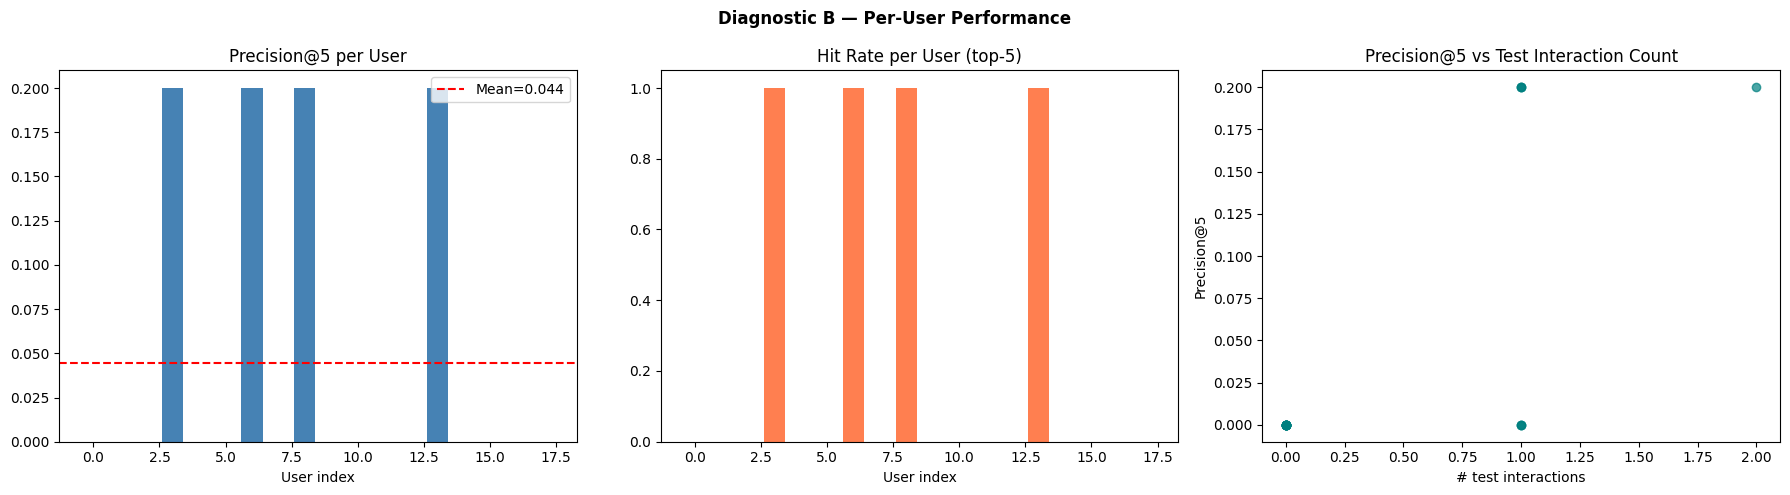

       user_idx  precision_at_5  hit_rate  n_test_interactions  \
count    18.000          18.000     7.000               18.000   
mean      8.500           0.044     0.571                0.444   
std       5.339           0.086     0.535                0.616   
min       0.000           0.000     0.000                0.000   
25%       4.250           0.000     0.000                0.000   
50%       8.500           0.000     1.000                0.000   
75%      12.750           0.000     1.000                1.000   
max      17.000           0.200     1.000                2.000   

       true_positives  false_positives  false_negatives  
count          18.000           18.000           18.000  
mean            0.222            1.722            0.222  
std             0.428            2.244            0.428  
min             0.000            0.000            0.000  
25%             0.000            0.000            0.000  
50%             0.000            0.000            0.000  

In [139]:
# B: Per-user Precision@5, hit rate, and ranking confusion matrix
from lightfm.evaluation import precision_at_k as pak
from scipy.sparse import csr_matrix as to_csr

# Keep one score per user row (including users with no test interactions)
per_user_p5 = pak(
    model, test_interactions,
    user_features=user_features_matrix,
    item_features=item_features_matrix,
    k=5,
    preserve_rows=True,
    num_threads=4,
)

test_csr = to_csr(test_interactions)
n_users_diag = test_csr.shape[0]
n_items_diag = test_csr.shape[1]

hit_rates = []
tp_list, fp_list, fn_list = [], [], []

for uid in range(n_users_diag):
    true_items = set(test_csr.getrow(uid).indices)
    if not true_items:
        hit_rates.append(np.nan)
        tp_list.append(0)
        fp_list.append(0)
        fn_list.append(0)
        continue

    scores = model.predict(
        user_ids=np.repeat(uid, n_items_diag),
        item_ids=np.arange(n_items_diag),
        user_features=user_features_matrix,
        item_features=item_features_matrix,
        num_threads=4,
    )

    top5_idx = set(np.argsort(scores)[-5:].tolist())
    hits = top5_idx & true_items
    tp_list.append(len(hits))
    fp_list.append(5 - len(hits))
    fn_list.append(len(true_items) - len(hits))
    hit_rates.append(1 if len(hits) > 0 else 0)

user_diag_df = pd.DataFrame({
    'user_idx': np.arange(n_users_diag),
    'precision_at_5': np.asarray(per_user_p5).reshape(-1),
    'hit_rate': np.asarray(hit_rates, dtype=float),
    'n_test_interactions': [test_csr.getrow(u).nnz for u in range(n_users_diag)],
    'true_positives': tp_list,
    'false_positives': fp_list,
    'false_negatives': fn_list,
})

fig_b, axes_b = plt.subplots(1, 3, figsize=(18, 5))
fig_b.suptitle('Diagnostic B — Per-User Performance', fontweight='bold')

axes_b[0].bar(range(n_users_diag), user_diag_df['precision_at_5'], color='steelblue')
axes_b[0].axhline(np.nanmean(user_diag_df['precision_at_5']), color='red', linestyle='--', label=f"Mean={np.nanmean(user_diag_df['precision_at_5']):.3f}")
axes_b[0].set_title('Precision@5 per User')
axes_b[0].set_xlabel('User index')
axes_b[0].legend()

axes_b[1].bar(range(n_users_diag), user_diag_df['hit_rate'].fillna(0), color='coral')
axes_b[1].set_title('Hit Rate per User (top-5)')
axes_b[1].set_xlabel('User index')

axes_b[2].scatter(user_diag_df['n_test_interactions'], user_diag_df['precision_at_5'], alpha=0.7, color='teal')
axes_b[2].set_title('Precision@5 vs Test Interaction Count')
axes_b[2].set_xlabel('# test interactions')
axes_b[2].set_ylabel('Precision@5')

plt.tight_layout()
plt.show()

print(user_diag_df.describe().round(3))

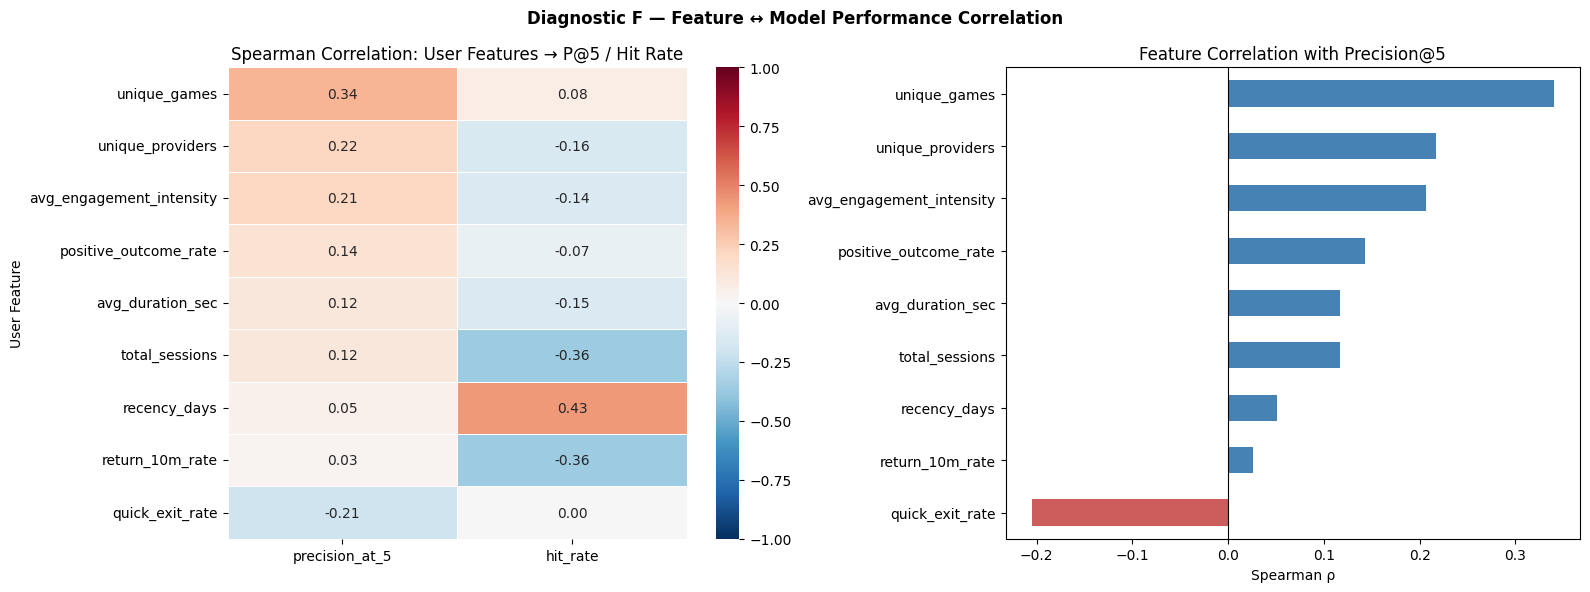


Key correlations with Precision@5:
  unique_games                   ρ = +0.340 ↑
  unique_providers               ρ = +0.217 ↑
  avg_engagement_intensity       ρ = +0.207 ↑
  positive_outcome_rate          ρ = +0.143 ↑
  avg_duration_sec               ρ = +0.117 ↑
  total_sessions                 ρ = +0.116 ↑
  recency_days                   ρ = +0.052 ↑
  return_10m_rate                ρ = +0.026 ↑
  quick_exit_rate                ρ = -0.205 ↓


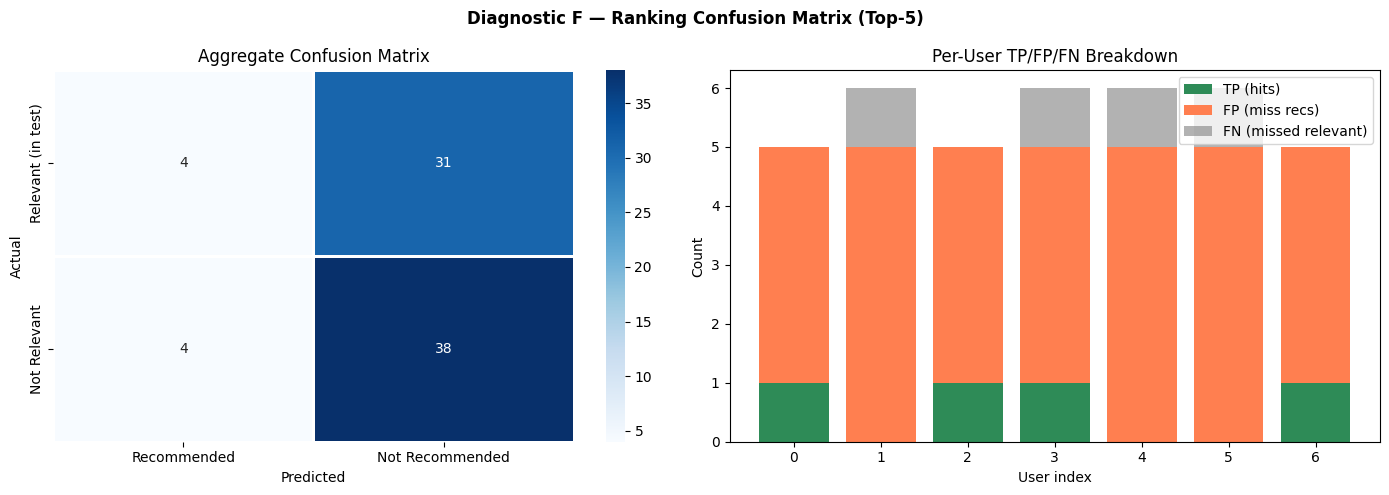


=== Ranking Confusion Summary (Top-5) ===
Total TP (hits):         4
Total FP (wrong recs):   31
Total FN (missed items): 4
Aggregate Precision@5:   0.1143
Aggregate Recall@5:      0.5000
Aggregate F1@5:          0.1860
Users evaluated:         7


In [140]:
# F: Feature ↔ Performance Correlation + Ranking Confusion Matrix

# --- 1. Feature-Performance Correlation ---
# Map user indices back to userIds via dataset mapping
idx_to_user = {v: k for k, v in user_id_map.items()}
user_diag_df['userId'] = user_diag_df['user_idx'].map(idx_to_user)

corr_df = user_diag_df.merge(user_features_df, on='userId', how='left')

feature_cols = [
    'total_sessions', 'unique_games', 'unique_providers',
    'avg_duration_sec', 'quick_exit_rate', 'return_10m_rate',
    'positive_outcome_rate', 'avg_engagement_intensity', 'recency_days',
]
feature_cols = [c for c in feature_cols if c in corr_df.columns and pd.api.types.is_numeric_dtype(corr_df[c])]

target_cols = ['precision_at_5', 'hit_rate']

if len(feature_cols) > 0:
    corr_matrix = corr_df[feature_cols + target_cols].corr(method='spearman')
    corr_with_perf = corr_matrix.loc[feature_cols, target_cols].sort_values('precision_at_5', ascending=False)

    fig_f1, axes_f1 = plt.subplots(1, 2, figsize=(16, 6))
    fig_f1.suptitle('Diagnostic F — Feature ↔ Model Performance Correlation', fontweight='bold')

    sns.heatmap(
        corr_with_perf, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
        vmin=-1, vmax=1, ax=axes_f1[0], linewidths=0.5,
    )
    axes_f1[0].set_title('Spearman Correlation: User Features → P@5 / Hit Rate')
    axes_f1[0].set_ylabel('User Feature')

    corr_with_perf['precision_at_5'].sort_values().plot(
        kind='barh', ax=axes_f1[1],
        color=corr_with_perf['precision_at_5'].sort_values().apply(
            lambda x: 'steelblue' if x >= 0 else 'indianred'
        ),
    )
    axes_f1[1].set_title('Feature Correlation with Precision@5')
    axes_f1[1].set_xlabel('Spearman ρ')
    axes_f1[1].axvline(0, color='black', linewidth=0.8)

    plt.tight_layout()
    plt.show()

    print('\nKey correlations with Precision@5:')
    for feat, val in corr_with_perf['precision_at_5'].items():
        sign = '↑' if val > 0 else '↓'
        print(f'  {feat:<30s} ρ = {val:+.3f} {sign}')
else:
    print('⚠️ No numeric user features available for correlation analysis.')

# --- 2. Ranking Confusion Matrix (Top-5) ---
eval_users = user_diag_df[user_diag_df['n_test_interactions'] > 0]
total_tp = eval_users['true_positives'].sum()
total_fp = eval_users['false_positives'].sum()
total_fn = eval_users['false_negatives'].sum()
total_tn = len(eval_users) * (n_items_diag - 5) - total_fn

confusion_data = np.array([[total_tp, total_fp],
                            [total_fn, total_tn]])

fig_f2, axes_f2 = plt.subplots(1, 2, figsize=(14, 5))
fig_f2.suptitle('Diagnostic F — Ranking Confusion Matrix (Top-5)', fontweight='bold')

sns.heatmap(
    confusion_data,
    annot=True, fmt='d', cmap='Blues',
    xticklabels=['Recommended', 'Not Recommended'],
    yticklabels=['Relevant (in test)', 'Not Relevant'],
    ax=axes_f2[0], linewidths=1,
)
axes_f2[0].set_title('Aggregate Confusion Matrix')
axes_f2[0].set_ylabel('Actual')
axes_f2[0].set_xlabel('Predicted')

eval_users_plot = eval_users.head(20)
axes_f2[1].bar(range(len(eval_users_plot)), eval_users_plot['true_positives'].values, label='TP (hits)', color='seagreen')
axes_f2[1].bar(range(len(eval_users_plot)), eval_users_plot['false_positives'].values,
            bottom=eval_users_plot['true_positives'].values, label='FP (miss recs)', color='coral')
axes_f2[1].bar(range(len(eval_users_plot)), eval_users_plot['false_negatives'].values,
            bottom=(eval_users_plot['true_positives'] + eval_users_plot['false_positives']).values,
            label='FN (missed relevant)', color='gray', alpha=0.6)
axes_f2[1].set_title('Per-User TP/FP/FN Breakdown')
axes_f2[1].set_xlabel('User index')
axes_f2[1].set_ylabel('Count')
axes_f2[1].legend()

plt.tight_layout()
plt.show()

precision_agg = total_tp / max(total_tp + total_fp, 1)
recall_agg = total_tp / max(total_tp + total_fn, 1)
f1_agg = 2 * precision_agg * recall_agg / max(precision_agg + recall_agg, 1e-9)

print(f'\n=== Ranking Confusion Summary (Top-5) ===')
print(f'Total TP (hits):         {total_tp}')
print(f'Total FP (wrong recs):   {total_fp}')
print(f'Total FN (missed items): {total_fn}')
print(f'Aggregate Precision@5:   {precision_agg:.4f}')
print(f'Aggregate Recall@5:      {recall_agg:.4f}')
print(f'Aggregate F1@5:          {f1_agg:.4f}')
print(f'Users evaluated:         {len(eval_users)}')

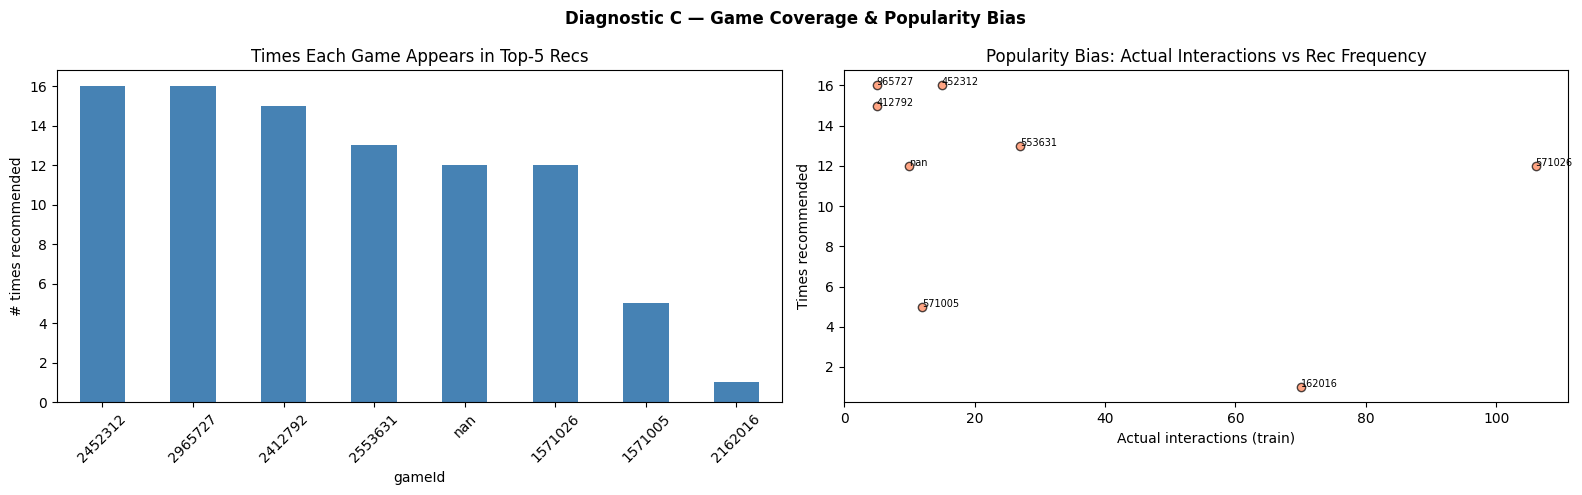

Games recommended at least once: 8 / 11
Coverage: 72.7%


In [138]:
# C: How often each game appears in top-5 recommendations across all users
from collections import Counter

all_recs = []
train_csr = to_csr(train_interactions)
n_items = train_csr.shape[1]

for uid in range(train_csr.shape[0]):
    scores = model.predict(
        user_ids=np.repeat(uid, n_items),
        item_ids=np.arange(n_items),
        user_features=user_features_matrix,
        item_features=item_features_matrix,
        num_threads=4,
    )
    known = set(train_csr.getrow(uid).indices)
    scores[list(known)] = -np.inf
    top5 = np.argsort(scores)[-5:]
    all_recs.extend([idx_to_item[i] for i in top5])

rec_counts = pd.Series(Counter(all_recs)).sort_values(ascending=False)
actual_counts = events_df['gameId'].value_counts()

fig_c, axes_c = plt.subplots(1, 2, figsize=(16, 5))
fig_c.suptitle('Diagnostic C — Game Coverage & Popularity Bias', fontweight='bold')

rec_counts.plot(kind='bar', ax=axes_c[0], color='steelblue')
axes_c[0].set_title('Times Each Game Appears in Top-5 Recs')
axes_c[0].set_xlabel('gameId')
axes_c[0].set_ylabel('# times recommended')
axes_c[0].tick_params(axis='x', rotation=45)

# Popularity bias check: rec frequency vs actual interaction frequency
common_games = rec_counts.index.intersection(actual_counts.index)
axes_c[1].scatter(
    actual_counts[common_games].values,
    rec_counts[common_games].values,
    alpha=0.7, color='coral', edgecolors='black'
)
for g in common_games:
    axes_c[1].annotate(str(g)[-6:], (actual_counts[g], rec_counts[g]), fontsize=7)
axes_c[1].set_title('Popularity Bias: Actual Interactions vs Rec Frequency')
axes_c[1].set_xlabel('Actual interactions (train)')
axes_c[1].set_ylabel('Times recommended')

plt.tight_layout()
plt.show()

print(f'Games recommended at least once: {len(rec_counts)} / {n_items}')
print(f'Coverage: {len(rec_counts)/n_items*100:.1f}%')

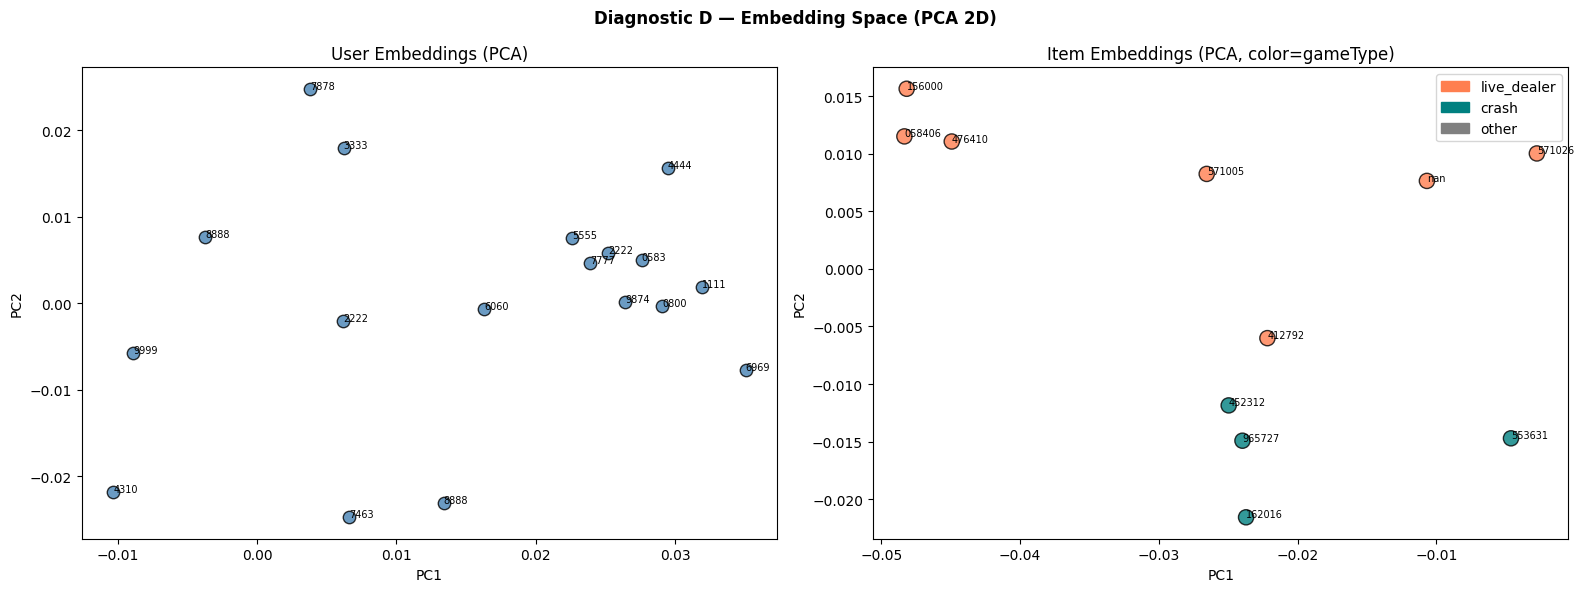

PCA explained variance: PC1=0.468, PC2=0.130


In [127]:
# D: Visualize user and item embeddings in 2D via PCA
from sklearn.decomposition import PCA

user_biases, user_embeddings = model.get_user_representations(features=user_features_matrix)
item_biases, item_embeddings = model.get_item_representations(features=item_features_matrix)

pca = PCA(n_components=2, random_state=42)
all_embeddings = np.vstack([user_embeddings, item_embeddings])
all_2d = pca.fit_transform(all_embeddings)

n_u = user_embeddings.shape[0]
user_2d = all_2d[:n_u]
item_2d = all_2d[n_u:]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Diagnostic D — Embedding Space (PCA 2D)', fontweight='bold')

# Users
axes[0].scatter(user_2d[:, 0], user_2d[:, 1], color='steelblue', s=80, alpha=0.8, edgecolors='black')
for i, uid in enumerate(active_users):
    axes[0].annotate(str(uid)[-4:], user_2d[i], fontsize=7)
axes[0].set_title('User Embeddings (PCA)')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')

# Items — color by game type if available
game_type_map = events_df.drop_duplicates('gameId').set_index('gameId')['gameType'].to_dict()
item_colors = [{'live_dealer': 'coral', 'crash': 'teal', 'slot': 'gold'}.get(
    game_type_map.get(gid, 'live_dealer'), 'gray') for gid in active_items]

axes[1].scatter(item_2d[:, 0], item_2d[:, 1], c=item_colors, s=120, alpha=0.8, edgecolors='black')
for i, gid in enumerate(active_items):
    axes[1].annotate(str(gid)[-6:], item_2d[i], fontsize=7)
axes[1].set_title('Item Embeddings (PCA, color=gameType)')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')

from matplotlib.patches import Patch
legend = [Patch(color='coral', label='live_dealer'),
          Patch(color='teal', label='crash'),
          Patch(color='gray', label='other')]
axes[1].legend(handles=legend)

plt.tight_layout()
plt.show()

print(f'PCA explained variance: PC1={pca.explained_variance_ratio_[0]:.3f}, PC2={pca.explained_variance_ratio_[1]:.3f}')

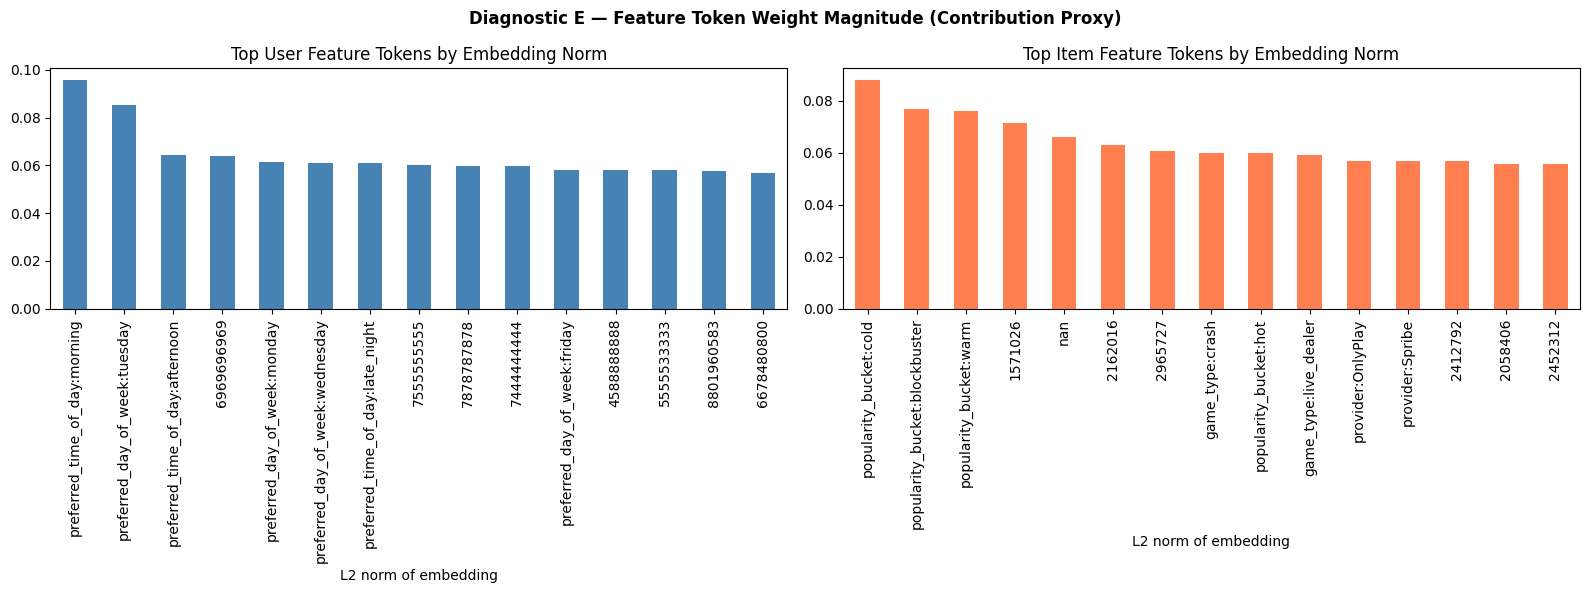

Top user tokens: {'preferred_time_of_day:morning': 0.09583771973848343, 'preferred_day_of_week:tuesday': 0.08514842391014099, 'preferred_time_of_day:afternoon': 0.0645388588309288, '6969696969': 0.06386533379554749, 'preferred_day_of_week:monday': 0.06129378080368042}
Top item tokens: {'popularity_bucket:cold': 0.0879615768790245, 'popularity_bucket:blockbuster': 0.07660043239593506, 'popularity_bucket:warm': 0.07608737796545029, '1571026': 0.07135825604200363, 'nan': 0.06611444056034088}


In [130]:
# E: Which user/item feature tokens have highest weight magnitude in embeddings
# Proxy for feature importance in LightFM

user_feat_map = dataset.mapping()[1]  # token -> col index
item_feat_map = dataset.mapping()[3]

_, user_feat_embeddings = model.get_user_representations(features=user_features_matrix)
_, item_feat_raw = model.get_item_representations(features=item_features_matrix)

# User feature token norms (contribution proxy)
user_feat_matrix_raw = dataset.build_user_features(
    (str(r['userId']), user_tokens(r)) for _, r in ufe.iterrows()
)
user_token_norms = {}
for token, idx in user_feat_map.items():
    col = user_feat_matrix_raw.getcol(idx)
    if col.nnz > 0:
        # Get embedding row for this feature index and compute norm
        emb = model.user_embeddings[idx] if idx < model.user_embeddings.shape[0] else None
        if emb is not None:
            user_token_norms[token] = float(np.linalg.norm(emb))

item_token_norms = {}
for token, idx in item_feat_map.items():
    emb = model.item_embeddings[idx] if idx < model.item_embeddings.shape[0] else None
    if emb is not None:
        item_token_norms[token] = float(np.linalg.norm(emb))

user_contrib = pd.Series(user_token_norms).sort_values(ascending=False)
item_contrib = pd.Series(item_token_norms).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Diagnostic E — Feature Token Weight Magnitude (Contribution Proxy)', fontweight='bold')

user_contrib.head(15).plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Top User Feature Tokens by Embedding Norm')
axes[0].set_xlabel('L2 norm of embedding')

item_contrib.head(15).plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Top Item Feature Tokens by Embedding Norm')
axes[1].set_xlabel('L2 norm of embedding')

plt.tight_layout()
plt.show()

print('Top user tokens:', user_contrib.head(5).to_dict())
print('Top item tokens:', item_contrib.head(5).to_dict())

## Potential Enhancements (Discuss with Senior)

- Better session modeling when robust `sessionId`, `roundsPlayed`, and true session boundaries are fully available.
- Device and entry point enrichment from clickstream/app telemetry instead of defaults.
- Temporal sequence modeling (next-game prediction using session order, not only aggregates).
- Real-time features (recent streaks, live context) for online serving.
- Cold-start handling via metadata embeddings and business-rule fallback.
- Contextual bandits / re-ranking for exploration vs exploitation balance.
- Stronger provider/gameType normalization dictionary managed centrally.

> These are intentionally **not implemented** in this notebook yet.

In [120]:
# Final pipeline readiness report

print('=' * 70)
print('REAL-DATA RECSYS PIPELINE — READINESS REPORT')
print('=' * 70)

print('\n[1] TDD schema validation')
missing_cols = [c for c in SCHEMA_COLUMNS if c not in events_df.columns]
print('Missing schema columns:', missing_cols if missing_cols else 'None ✅')

print('\n[2] Enum coverage checks')
game_types_present = sorted(events_df['gameType'].dropna().unique().tolist())
providers_present = sorted(events_df['provider'].dropna().unique().tolist())
print('gameType values:', game_types_present)
print('provider values:', providers_present)

invalid_game_types = sorted(set(game_types_present) - set(VALID_GAME_TYPES))
invalid_providers = sorted(set(providers_present) - set(VALID_PROVIDERS))
print('Invalid gameType values:', invalid_game_types if invalid_game_types else 'None ✅')
print('Invalid provider values:', invalid_providers if invalid_providers else 'None ✅')

print('\n[3] Output datasets')
print(f'events_df:       {events_df.shape}')
print(f'user_features_df:{user_features_df.shape}')
print(f'game_features_df:{game_features_df.shape}')
print(f'user_game_df:    {user_game_df.shape}')
print(f'model_ready_df:  {model_ready_df.shape}')

print('\n[4] Assumptions applied')
print('- deviceType defaulted to "mobile" (source unavailable)')
print('- entryPoint defaulted to "direct" (source unavailable)')
print('- roundsPlayed proxied as 1 per settled event')
print('- sessionId from transaction _id (fallback index-based id)')
print('- provider normalized to HUB88/Evolution/EZUGI/Spribe/OnlyPlay')

print('\nPipeline is schema-aligned and ready for downstream model training steps.')
print('=' * 70)

REAL-DATA RECSYS PIPELINE — READINESS REPORT

[1] TDD schema validation
Missing schema columns: None ✅

[2] Enum coverage checks
gameType values: ['crash', 'live_dealer']
provider values: ['Evolution', 'HUB88', 'OnlyPlay', 'Spribe']
Invalid gameType values: None ✅
Invalid provider values: None ✅

[3] Output datasets
events_df:       (254, 17)
user_features_df:(18, 17)
game_features_df:(11, 11)
user_game_df:    (36, 13)
model_ready_df:  (36, 38)

[4] Assumptions applied
- deviceType defaulted to "mobile" (source unavailable)
- entryPoint defaulted to "direct" (source unavailable)
- roundsPlayed proxied as 1 per settled event
- sessionId from transaction _id (fallback index-based id)
- provider normalized to HUB88/Evolution/EZUGI/Spribe/OnlyPlay

Pipeline is schema-aligned and ready for downstream model training steps.


In [121]:
# 1. Provider mapping sahi hua?
print(events_df['provider'].value_counts())
# Expected: Evolution, Spribe, OnlyPlay visible — NOT sab HUB88

# 2. GameType mapping sahi hua?
print(events_df['gameType'].value_counts())
# Expected: crash alag dikhe (Aviator etc), live_dealer alag

# 3. implicit_score range sahi hai?
print(user_game_df['implicit_score'].describe())
# Expected: 0.0 - 1.0, no NaNs

provider
Evolution    132
Spribe        70
OnlyPlay      47
HUB88          5
Name: count, dtype: int64
gameType
live_dealer    137
crash          117
Name: count, dtype: int64
count    36.000000
mean      0.424186
std       0.172386
min       0.199300
25%       0.314900
50%       0.371500
75%       0.460450
max       0.914600
Name: implicit_score, dtype: float64


In [122]:
print(user_game_df.columns.tolist())

['userId', 'gameId', 'interaction_count', 'avg_duration_sec', 'avg_rounds', 'positive_outcome_rate', 'return_10m_rate', 'avg_engagement_intensity', 'last_interaction_ts', 'dominant_game_type', 'dominant_provider', 'recency_days', 'implicit_score']
